# Tarea 2: Análisis de panel

**Alumno**: Álvaro Contreras Zúñiga

**Matricula**: 2021433031

In [1]:
#Importación librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
from sklearn.preprocessing import StandardScaler
import datetime
import random
import linearmodels.panel as lmp
from linearmodels.iv import IV2SLS
from scipy import stats
import numpy.linalg as la
from linearmodels.panel import PanelOLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


**Diccionario**
- "iso_code": "Country or region code",
- "date": "Date of the record",
- "retail_and_recreation_percent_change_from_baseline": "Change in retail/recreation activity",
- "grocery_and_pharmacy_percent_change_from_baseline": "Change in grocery/pharmacy activity",
- "parks_percent_change_from_baseline": "Change in park visits",
- "transit_stations_percent_change_from_baseline": "Change in transit station activity",
- "workplaces_raw": "Raw workplace activity data",
- "residential_percent_change_from_baseline": "Change in residential activity",
- "trend": "Trend indicator",
- "workplaces": "Processed workplace activity data",
- "Valor_Stringency_Index": "Stringency index value",
- "Valor_GovernmentResponseIndex": "Government response index value",
- "Valor_EconomicSupportIndex": "Economic support index value",
- "Valor_Containment_Health_index": "Containment and health index value",
- "workplace_closing": "Workplace closing indicator",
- "daily_cases": "Daily reported cases",
- "week": "Week number",
- "year": "Year",
- "CODE": "Region code",
- "NAME": "Region name",
- "Population": "Population of the region",
- "agriculture": "Agriculture sector data",
- "industry": "Industry sector data",
- "construction": "Construction sector data",
- "age_dependency": "Age dependency ratio",
- "old_age_dependency": "Old age dependency ratio",
- "young_age_dependency": "Young age dependency ratio",
- "sex_ratio": "Sex ratio",
- "unemp": "Unemployment rate",
- "f_unemp": "Female unemployment rate",
- "m_unemp": "Male unemployment rate",
- "foreigners": "Foreign population percentage",
- "country": "Country name"

| Variable | Descripción Original | Definición en el Contexto del Modelo |
| :--- | :--- | :--- |
| **`iso_code`** | Country or region code | Código estándar ISO de la región o país. |
| **`date`** | Date of the record | Fecha exacta de la observación. Actúa como la coordenada temporal del panel. |
| **`retail_and_recreation_percent_change_from_baseline`** | Change in retail/recreation activity | Variación porcentual en visitas a restaurantes, centros comerciales, museos y cines respecto a la línea base pre-pandemia. |
| **`grocery_and_pharmacy_percent_change_from_baseline`** | Change in grocery/pharmacy activity | Variación porcentual en visitas a supermercados y farmacias respecto a la línea base. |
| **`parks_percent_change_from_baseline`** | Change in park visits | Variación porcentual en visitas a parques respecto a la línea base. |
| **`transit_stations_percent_change_from_baseline`** | Change in transit station activity | Variación porcentual en el uso de estaciones de transporte público (metro, buses, trenes). |
| **`workplaces_raw`** | Raw workplace activity data | Datos crudos (sin suavizado matemático) de la variación de movilidad hacia lugares de trabajo. |
| **`residential_percent_change_from_baseline`** | Change in residential activity | Variación porcentual en el tiempo de permanencia en zonas residenciales (hogares). |
| **`trend`** | Trend indicator | Variable matemática o estadística que captura la tendencia temporal subyacente de la serie. |
| **`workplaces`** | Processed workplace activity data |  Variación porcentual procesada en la movilidad hacia lugares de trabajo respecto a la línea base. |
| **`Valor_Stringency_Index`** | Stringency index value | Índice de Rigurosidad (0-100). Mide la severidad de las políticas de cierre gubernamentales. |
| **`Valor_GovernmentResponseIndex`** | Government response index value | Índice de Respuesta Gubernamental (0-100). Combina restricciones de movilidad, medidas de salud y apoyo económico. |
| **`Valor_EconomicSupportIndex`** | Economic support index value | Índice de Apoyo Económico (0-100). Mide las medidas de ayuda financiera estatal a los ciudadanos (ej. subsidios, alivio de deudas). |
| **`Valor_Containment_Health_index`** | Containment and health index value | Índice de Contención y Salud (0-100). Combina restricciones de movilidad con medidas de salud pública (testeo, mascarillas). |
| **`workplace_closing`** | Workplace closing indicator |  Nivel de severidad de la política legal respecto al cierre obligatorio de lugares de trabajo. |
| **`daily_cases`** | Daily reported cases | Número de casos nuevos de COVID-19 reportados diariamente. |
| **`week`** | Week number | Contador numérico de la semana dentro de la muestra temporal del panel. |
| **`year`** | Year | Año cronológico de la observación (2020, 2021, etc.). |
| **`CODE`** | Region code | Código interno único para identificar a cada ciudad/región. Actúa como el identificador de entidad (Individuo $i$) del panel. |
| **`NAME`** | Region name | Nombre geográfico de la ciudad o región analizada. |
| **`Population`** | Population of the region | Población total de la ciudad o región. |
| **`agriculture`** | Agriculture sector data | Proporción del sector agrícola dentro de la matriz productiva de la región. |
| **`industry`** | Industry sector data | Proporción del sector industrial dentro de la matriz productiva de la región. |
| **`construction`** | Construction sector data | Proporción del sector de la construcción dentro de la matriz productiva de la región. |
| **`age_dependency`** | Age dependency ratio | Tasa de dependencia demográfica global. Mide la proporción de la población económicamente inactiva (jóvenes y ancianos) respecto a la fuerza laboral activa. |
| **`old_age_dependency`** | Old age dependency ratio | Tasa de dependencia demográfica exclusiva de la tercera edad. |
| **`young_age_dependency`** | Young age dependency ratio | Tasa de dependencia demográfica exclusiva de jóvenes e infantes. |
| **`sex_ratio`** | Sex ratio | Razón de sexo (proporción demográfica entre hombres y mujeres en el territorio). |
| **`unemp`** | Unemployment rate | Tasa global de desempleo de la región. |
| **`f_unemp`** | Female unemployment rate | Tasa específica de desempleo femenino de la región. |
| **`m_unemp`** | Male unemployment rate | Tasa específica de desempleo masculino de la región. |
| **`foreigners`** | Foreign population percentage | Porcentaje de población residente de origen extranjero o inmigrante. |
| **`country`** | Country name | Identificador nominal (texto) del país al que pertenece la observación regional. |

**Pregunta 1**

La base de datos de este estudio contiene información de varias ciudades durante la época del COVID-19. En esta base se registra cosas como la cantidad de casos diarios, las restricciones del gobierno (cuarentenas, cierres de comercios) y variables de la población (tasa de desempleo, porcentaje de extranjeros, etc.).

Objetivo del estudio: El objetivo es evaluar el impacto de las restricciones gubernamentales sobre la movilidad laboral durante la pandemia, se quiere la pregunta ¿En qué medida las restricciones sanitarias y de confinamiento dictadas por los gobiernos locales redujeron la movilidad de las personas hacia sus lugares de trabajo?

Hipótesis principal: Existe una relación inversa y estadísticamente significativa entre el nivel de rigurosidad de las medidas gubernamentales (Valor_Stringency_Index o workplace_closing) y la variación de la movilidad laboral (workplaces), se espera que a mayor severidad de las restricciones, se produzca una disminución en la asistencia presencial a los puestos de trabajo.


En primer lugar se carga la data original, se solicita el número de filas y columnas para tener un registro de la cantidad de datos que se tienen. Luego de esto, se eliminan las columnas que no se encuentran como variables en el diccionario ya que no se tiene información sobre estas. Por último se obtiene la informacion general utilizando df.info.

In [2]:

# Cargar base de datos original
df_inicial = pd.read_csv('dataset_prueba.csv', delimiter=",", decimal='.')
print(f"Dimensiones originales: {df_inicial.shape[0]} filas, {df_inicial.shape[1]} columnas\n")

# Eliminación de columnas que no estan en el diccionario
columnas_a_borrar = ['d1', 'd2', 'd3', 'd4', 'd5', 'd6', 'edu2', 'edu3']
df = df_inicial.drop(columns=columnas_a_borrar)
print(f"Dimensiones tras borrar variables fuera del diccionario: {df.shape[0]} filas, {df.shape[1]} columnas\n")

# Informacion general actual y tipos de datos

df.info()



Dimensiones originales: 12040 filas, 41 columnas

Dimensiones tras borrar variables fuera del diccionario: 12040 filas, 33 columnas

<class 'pandas.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 33 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   iso_code                                            12040 non-null  str    
 1   date                                                12040 non-null  str    
 2   retail_and_recreation_percent_change_from_baseline  12040 non-null  float64
 3   grocery_and_pharmacy_percent_change_from_baseline   12040 non-null  float64
 4   parks_percent_change_from_baseline                  12040 non-null  float64
 5   transit_stations_percent_change_from_baseline       12040 non-null  float64
 6   workplaces_raw                                      12040 non-null  float64
 7   residential_percent_change_from_bas

In [3]:
pd.set_option('display.max_columns', None)

df

,iso_code,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,Valor_Stringency_Index,Valor_GovernmentResponseIndex,Valor_EconomicSupportIndex,Valor_Containment_Health_index,workplace_closing,daily_cases,week,year,CODE,NAME,Population,agriculture,industry,construction,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners,country
0,DE-BE,2020-02-17,6.0,3.00,15.00,4.0,1.00,0.00,9.266668,4.244073,0.00,0.00,0.0,0.00,0.0,0.0160,1,2020,DE001C,Berlin,3669.491,0.000419,0.076745,0.046983,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.071170,9.0,DE
1,DE-BE,2020-02-24,1.6,0.00,8.60,0.0,0.20,0.60,5.006175,2.468286,0.00,0.00,0.0,0.00,0.0,0.0160,2,2020,DE001C,Berlin,3669.491,0.000419,0.076745,0.046983,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.071170,9.0,DE
2,DE-BE,2020-03-02,2.6,6.40,8.20,-0.4,0.40,1.00,-3.765428,-2.845394,0.00,0.00,0.0,0.00,0.0,0.0594,3,2020,DE001C,Berlin,3669.491,0.000419,0.076745,0.046983,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.071170,9.0,DE
3,DE-BE,2020-03-09,-3.4,3.40,-1.00,-5.8,-0.60,1.80,-12.537031,-11.510297,0.00,0.00,0.0,0.00,0.0,0.5572,4,2020,DE001C,Berlin,3669.491,0.000419,0.076745,0.046983,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.071170,9.0,DE
4,DE-BE,2020-03-16,-11.8,11.40,-4.60,-16.0,-7.80,4.60,-21.308634,-21.800890,0.00,0.00,0.0,0.00,0.0,3.2780,5,2020,DE001C,Berlin,3669.491,0.000419,0.076745,0.046983,0.592713,0.290913,0.306017,103.377815,8.0,0.086068,0.071170,9.0,DE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12035,SE-M,2022-09-19,-3.4,5.20,50.60,-16.0,-12.80,2.20,-15.047446,-8.365623,11.11,16.67,0.0,19.05,0.0,0.0000,136,2022,SE003C,Malmö,333.633,0.001360,0.070238,0.061295,0.617317,0.370739,0.246578,102.195691,15.0,0.165522,0.134529,8.0,SE
12036,SE-M,2022-09-26,-0.2,7.40,62.60,-16.8,-12.00,1.80,-15.175740,-6.167200,11.11,14.58,0.0,16.67,0.0,0.0000,137,2022,SE003C,Malmö,333.633,0.001360,0.070238,0.061295,0.617317,0.370739,0.246578,102.195691,15.0,0.165522,0.134529,8.0,SE
12037,SE-M,2022-10-03,-1.2,6.00,31.80,-17.8,-10.80,2.40,-15.304033,-5.122127,11.11,14.58,0.0,16.67,0.0,0.0000,138,2022,SE003C,Malmö,333.633,0.001360,0.070238,0.061295,0.617317,0.370739,0.246578,102.195691,15.0,0.165522,0.134529,8.0,SE
12038,SE-M,2022-10-10,-3.2,4.20,43.80,-16.8,-8.80,2.20,-15.432327,-5.921463,11.11,14.58,0.0,16.67,0.0,0.0000,139,2022,SE003C,Malmö,333.633,0.001360,0.070238,0.061295,0.617317,0.370739,0.246578,102.195691,15.0,0.165522,0.134529,8.0,SE


Para revisar las variables se ejecuta este script para observar su cardinalidad

In [4]:
#Diagnóstico de Valores Únicos


print("--- Diagnóstico de Valores Únicos (Variables del Modelo) ---")
for col in df.columns:
    valores_unicos = df[col].nunique()
    tipo_dato = df[col].dtype
    
    if valores_unicos < 50:
        print(f"[{tipo_dato}] '{col}': {valores_unicos} valores -> {df[col].unique()}")
    else:
        print(f"[{tipo_dato}] '{col}': {valores_unicos} valores (Alta cardinalidad)")



--- Diagnóstico de Valores Únicos (Variables del Modelo) ---
[str] 'iso_code': 54 valores (Alta cardinalidad)
[str] 'date': 140 valores (Alta cardinalidad)
[float64] 'retail_and_recreation_percent_change_from_baseline': 695 valores (Alta cardinalidad)
[float64] 'grocery_and_pharmacy_percent_change_from_baseline': 586 valores (Alta cardinalidad)
[float64] 'parks_percent_change_from_baseline': 1580 valores (Alta cardinalidad)
[float64] 'transit_stations_percent_change_from_baseline': 803 valores (Alta cardinalidad)
[float64] 'workplaces_raw': 457 valores (Alta cardinalidad)
[float64] 'residential_percent_change_from_baseline': 220 valores (Alta cardinalidad)
[float64] 'trend': 7560 valores (Alta cardinalidad)
[float64] 'workplaces': 7560 valores (Alta cardinalidad)
[float64] 'Valor_Stringency_Index': 321 valores (Alta cardinalidad)
[float64] 'Valor_GovernmentResponseIndex': 362 valores (Alta cardinalidad)
[float64] 'Valor_EconomicSupportIndex': 23 valores -> [  0.   55.   62.5  87.5  85.

Se realiza un conteo de datos faltantes

In [5]:
# Diagnóstico de Datos Faltantes 
print("\n--- Conteo de Valores Nulos ---")
nulos = df.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

print(df.isnull().sum())




--- Conteo de Valores Nulos ---
Series([], dtype: int64)
iso_code                                              0
date                                                  0
retail_and_recreation_percent_change_from_baseline    0
grocery_and_pharmacy_percent_change_from_baseline     0
parks_percent_change_from_baseline                    0
transit_stations_percent_change_from_baseline         0
workplaces_raw                                        0
residential_percent_change_from_baseline              0
trend                                                 0
workplaces                                            0
Valor_Stringency_Index                                0
Valor_GovernmentResponseIndex                         0
Valor_EconomicSupportIndex                            0
Valor_Containment_Health_index                        0
workplace_closing                                     0
daily_cases                                           0
week                                          

Se realiza un nuevo control de la información

In [6]:
#             Control de pérdida de información

dim_final = df.shape
print(f"--- Dimensiones Finales tras Limpieza e Indexación ---")
print(f"Observaciones retenidas: {dim_final[0]} | Variables finales: {dim_final[1]}")
print(f"Pérdida de filas por atrición: {df_inicial.shape[0] - dim_final[0]}\n")

--- Dimensiones Finales tras Limpieza e Indexación ---
Observaciones retenidas: 12040 | Variables finales: 33
Pérdida de filas por atrición: 0



Se convierte la fecha a datetime

In [7]:
df['date'] = pd.to_datetime(df['date']) 

Se hace una revision de cada columna 

In [8]:
df.describe()

,date,retail_and_recreation_percent_change_from_baseline,grocery_and_pharmacy_percent_change_from_baseline,parks_percent_change_from_baseline,transit_stations_percent_change_from_baseline,workplaces_raw,residential_percent_change_from_baseline,trend,workplaces,Valor_Stringency_Index,Valor_GovernmentResponseIndex,Valor_EconomicSupportIndex,Valor_Containment_Health_index,workplace_closing,daily_cases,week,year,Population,agriculture,industry,construction,age_dependency,old_age_dependency,young_age_dependency,sex_ratio,unemp,f_unemp,m_unemp,foreigners
count,12040,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000,12040.000000
mean,2021-06-17 12:00:00,-16.437272,5.124340,49.675619,-17.602313,-25.002928,7.071179,-19.004247,-18.667353,27.486254,30.636789,30.955150,30.591686,0.850831,2355.733422,70.500000,2020.971429,745.474163,0.006719,0.115376,0.053282,0.653934,0.320896,0.334465,106.714479,12.220515,0.113865,0.121292,8.145515
min,2020-02-17 00:00:00,-95.600000,-66.200000,-95.800000,-88.600000,-87.000000,-3.800000,-80.071581,-76.787132,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2020.000000,201.048000,0.000419,0.036570,0.018195,0.520499,0.255039,0.238051,91.448785,3.000000,0.035794,0.024618,2.000000
25%,2020-10-17 06:00:00,-26.400000,-3.200000,4.800000,-31.800000,-32.400000,3.200000,-22.614732,-24.358379,0.000000,0.000000,0.000000,0.000000,0.000000,0.037200,35.750000,2020.000000,246.794000,0.001350,0.081304,0.037263,0.609178,0.280293,0.282108,103.522992,6.000000,0.061770,0.052677,6.000000
50%,2021-06-17 12:00:00,-11.400000,6.200000,34.200000,-18.400000,-22.800000,5.600000,-17.430940,-16.819961,15.858000,32.030000,0.000000,36.610000,0.000000,632.010400,70.500000,2021.000000,346.790500,0.003547,0.107078,0.052972,0.650998,0.306745,0.331407,107.013220,8.000000,0.085044,0.078852,9.000000
75%,2022-02-15 18:00:00,-3.600000,15.000000,78.800000,-4.400000,-14.400000,9.400000,-13.324697,-10.883994,53.420000,60.160000,75.000000,59.230000,2.000000,3815.644400,105.250000,2022.000000,620.523000,0.010854,0.148541,0.069632,0.681714,0.338193,0.366313,109.531509,18.000000,0.149918,0.163352,11.000000
max,2022-10-17 00:00:00,74.600000,83.600000,631.000000,123.200000,6.600000,42.600000,12.355647,19.057630,93.520000,81.306000,100.000000,85.420000,3.000000,22203.314200,140.000000,2022.000000,10274.884000,0.071369,0.232640,0.152669,0.837478,0.485328,0.507336,115.752855,36.000000,0.328653,0.427472,15.000000
std,NaN,21.599436,15.707311,71.697845,24.540594,14.681099,6.022794,9.857500,11.801356,29.835937,30.244900,36.364281,29.943118,0.997067,3154.914356,40.415166,0.792343,1277.341567,0.009605,0.044462,0.018237,0.072849,0.052749,0.062533,4.247242,8.265315,0.070448,0.093873,2.991933


In [9]:
print("--- Revisión de columna por columna ---")

for col in df.columns:
    tipo = df[col].dtype
    print(f"\n * Variable: '{col}' | Tipo: {tipo}")
    
    # Si la columna es un número 
    if pd.api.types.is_numeric_dtype(df[col]):
        minimo = df[col].min()
        maximo = df[col].max()
        media = df[col].mean()
        
        print(f"   Rango de valores : De {minimo:.2f} a {maximo:.2f}")
        print(f"   Promedio (Media) : {media:.2f}")
        
        # Alerta visual para detectar posibles anomalías rápidamente
        if minimo < 0:
            print("   ALERTA: Contiene valores negativos. (Verificar si tiene sentido lógico).")
            
    # Si la columna es texto o fecha 
    else:
        unicos = df[col].nunique()
        print(f"   Categorías únicas: {unicos}")
        # Muestra los 5 valores que más se repiten para detectar errores de tipeo
        print(f"   Valores más comunes:\n{df[col].value_counts().head(5).to_string()}")

--- Revisión de columna por columna ---

 * Variable: 'iso_code' | Tipo: str
   Categorías únicas: 54
   Valores más comunes:
iso_code
DE-NW    2100
DE-BW     560
DE-BY     420
DE-HE     420
DE-SN     420

 * Variable: 'date' | Tipo: datetime64[us]
   Categorías únicas: 140
   Valores más comunes:
date
2020-02-17    86
2020-02-24    86
2020-03-02    86
2020-03-09    86
2020-03-16    86

 * Variable: 'retail_and_recreation_percent_change_from_baseline' | Tipo: float64
   Rango de valores : De -95.60 a 74.60
   Promedio (Media) : -16.44
   ALERTA: Contiene valores negativos. (Verificar si tiene sentido lógico).

 * Variable: 'grocery_and_pharmacy_percent_change_from_baseline' | Tipo: float64
   Rango de valores : De -66.20 a 83.60
   Promedio (Media) : 5.12
   ALERTA: Contiene valores negativos. (Verificar si tiene sentido lógico).

 * Variable: 'parks_percent_change_from_baseline' | Tipo: float64
   Rango de valores : De -95.80 a 631.00
   Promedio (Media) : 49.68
   ALERTA: Contiene va

Distribuciones para 28 variables...


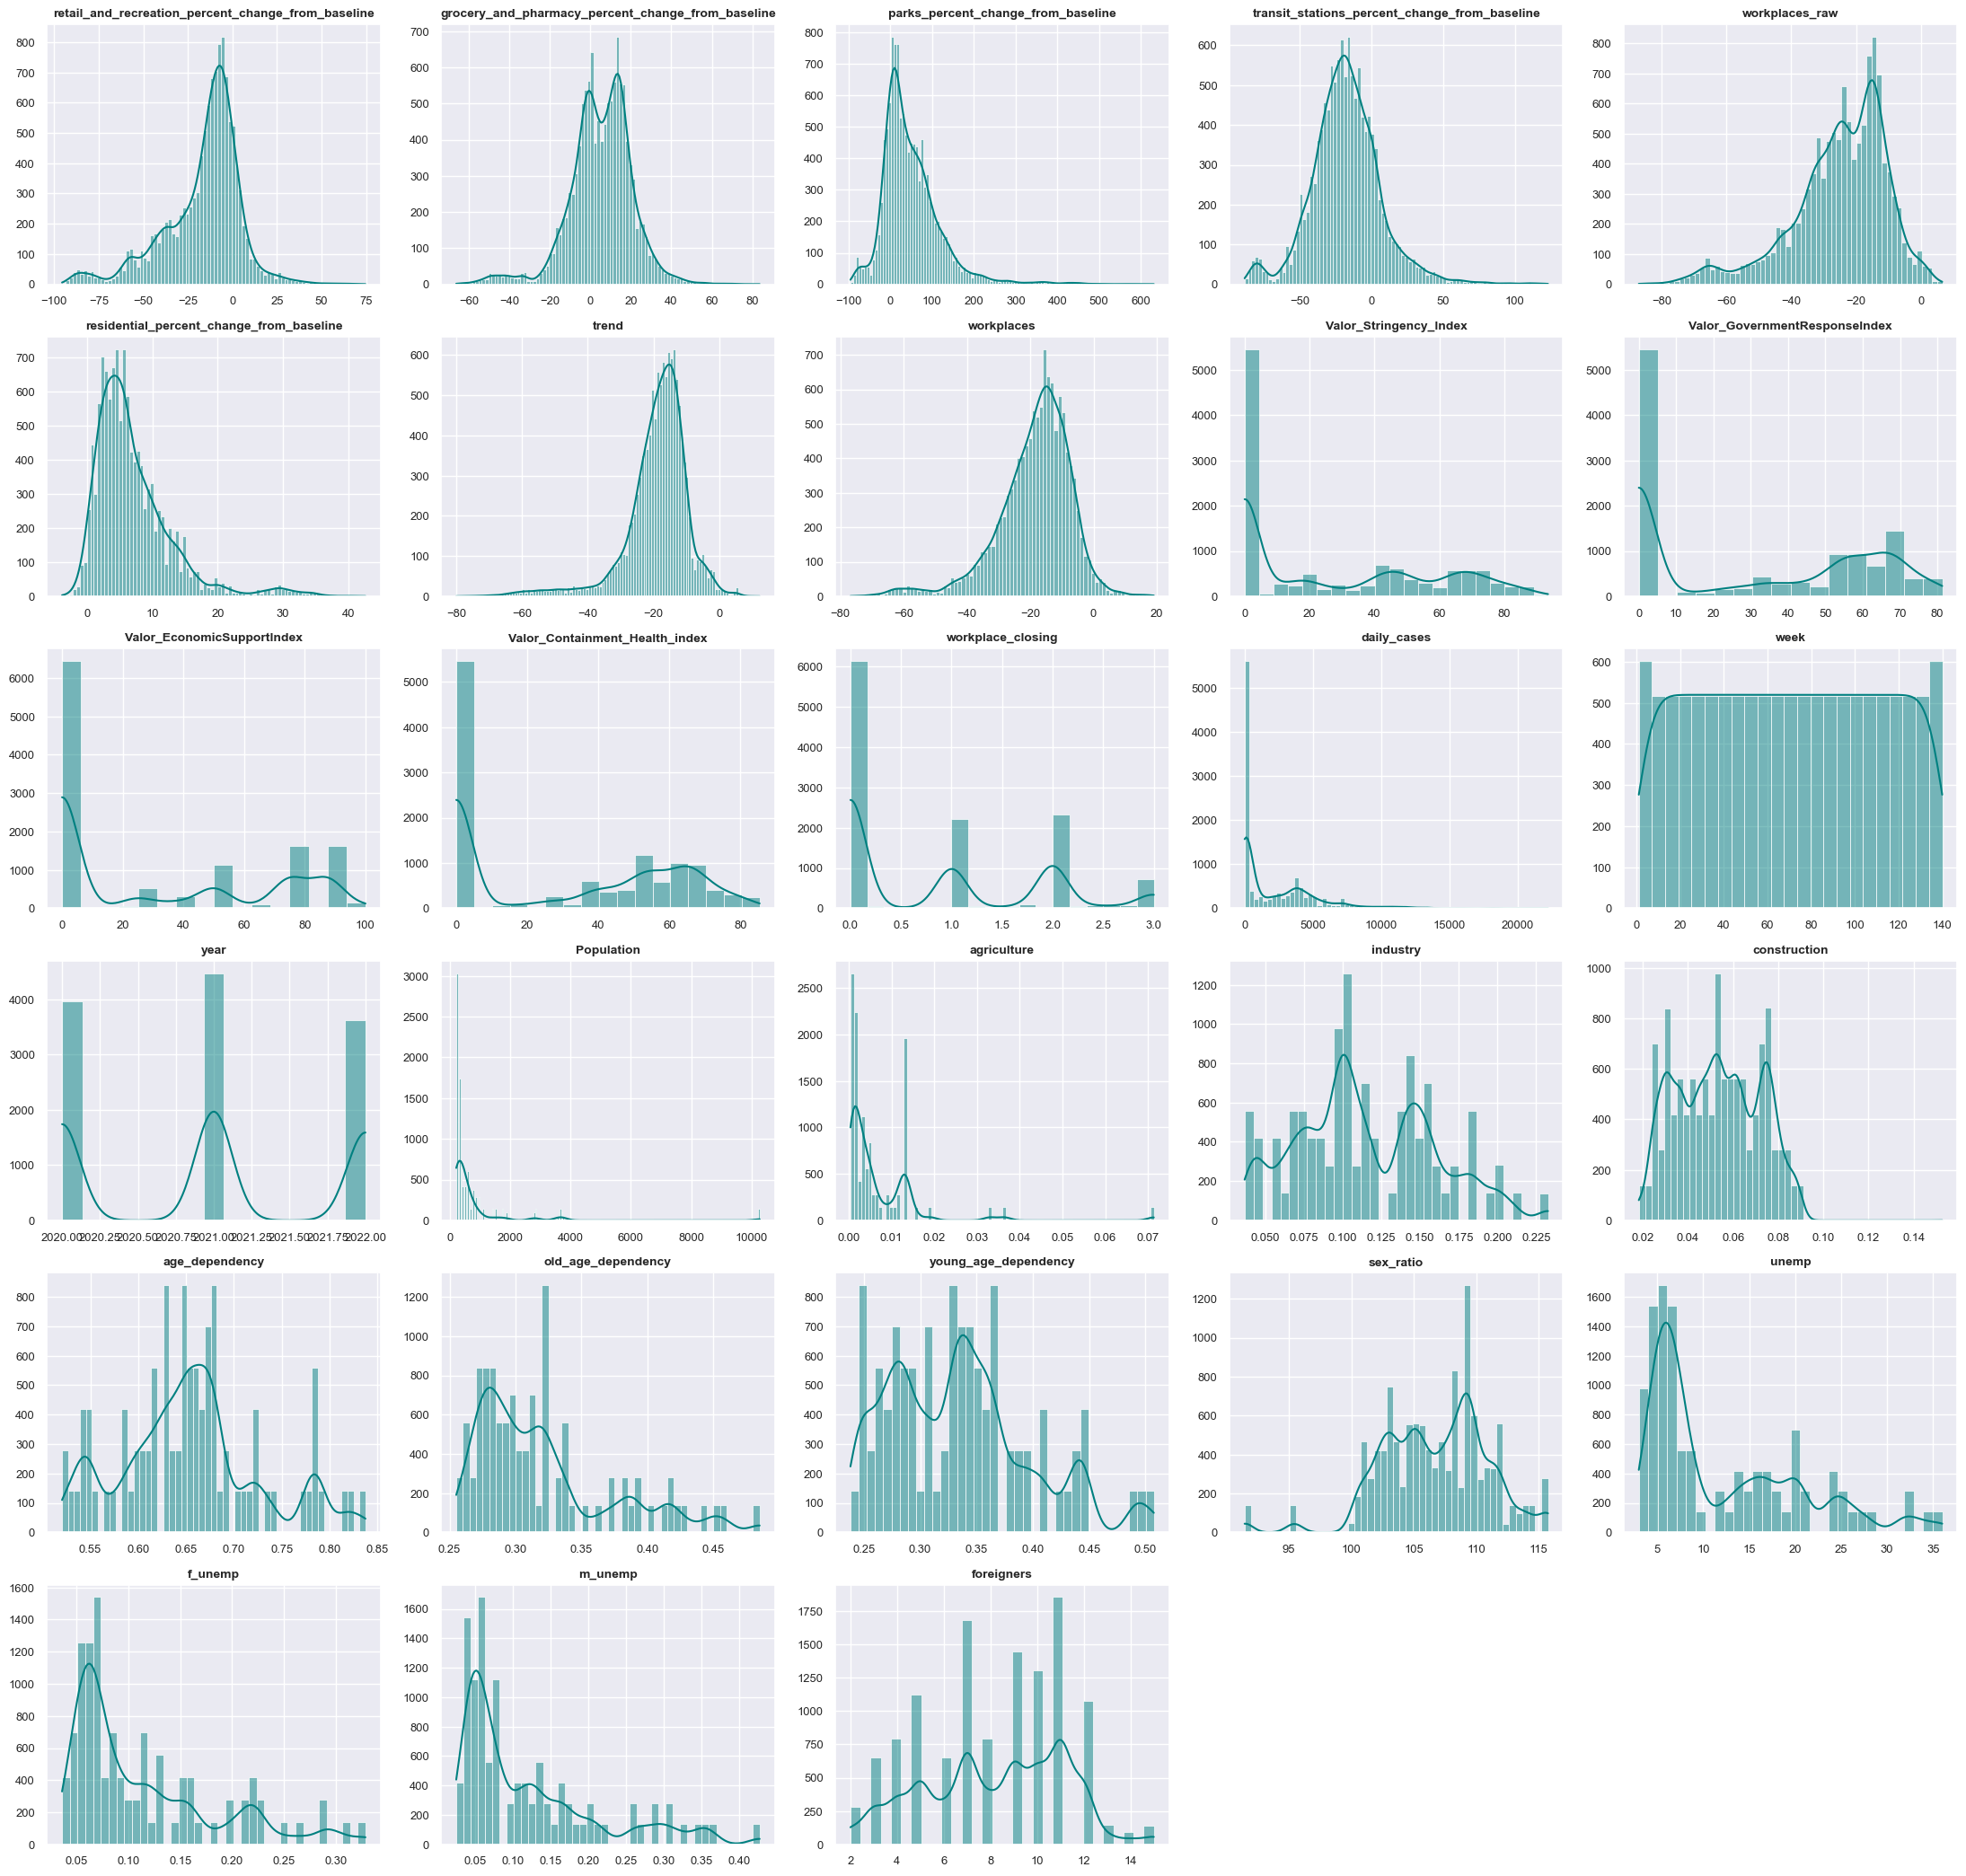

Boxplots para 28 variables...


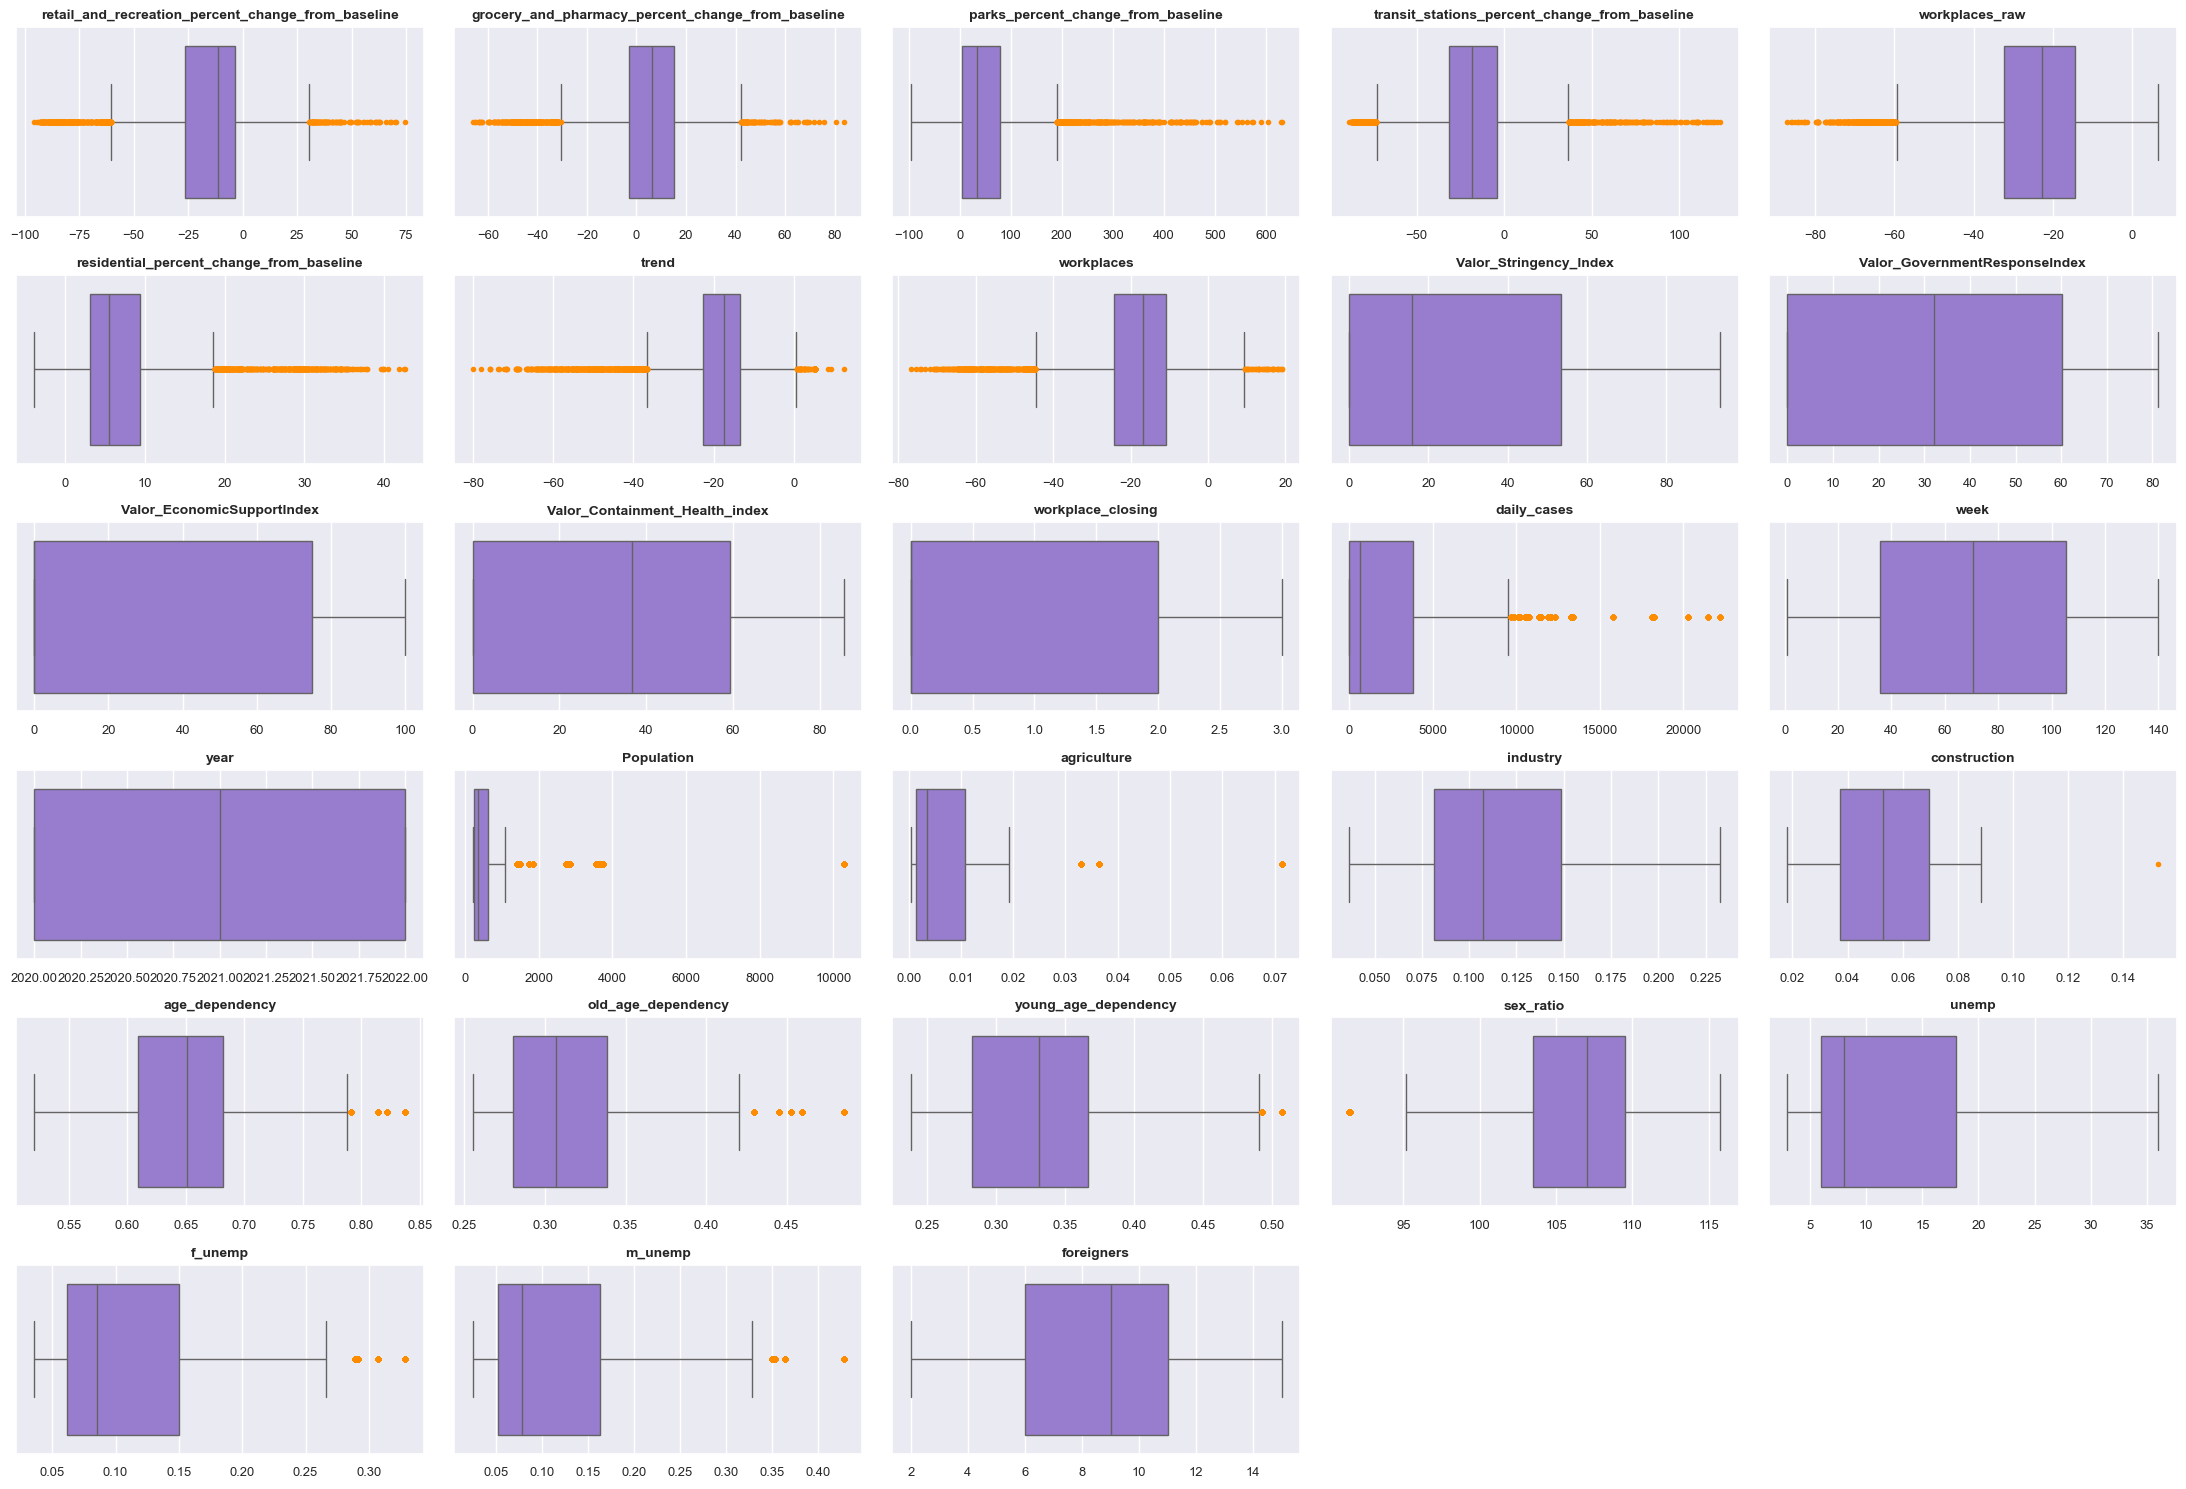

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Configuracion de estilo visual premium
sns.set_style("darkgrid")
sns.set_context("notebook", font_scale=0.85)

# Obtener lista de columnas numericas usando exclusion
columnas_num = df.select_dtypes(exclude=['object', 'datetime']).columns
total_columnas = len(columnas_num)

# Calcular disposicion de los graficos (5 columnas)
cols_grafico = 5
filas_grafico = (total_columnas + cols_grafico - 1) // cols_grafico

# Parte 1: Graficos de Distribucion (Histogramas + Curvas de Densidad)
fig_hist, ejes_hist = plt.subplots(filas_grafico, cols_grafico, figsize=(22, 3.5 * filas_grafico))
ejes_planos_hist = ejes_hist.flatten()

print(f"Distribuciones para {total_columnas} variables...")

for eje, nombre_col in zip(ejes_planos_hist, columnas_num):
    sns.histplot(
        data=df, 
        x=nombre_col, 
        kde=True, 
        ax=eje, 
        color='teal', 
        alpha=0.5,
        linewidth=0.5
    )
    eje.set_title(nombre_col, fontsize=10, fontweight='bold')
    eje.set_xlabel('')
    eje.set_ylabel('')

# Ocultar paneles sobrantes en la grilla
for idx in range(total_columnas, len(ejes_planos_hist)):
    fig_hist.delaxes(ejes_planos_hist[idx])

plt.tight_layout()
plt.show()

# Parte 2: Boxplots para Deteccion de Valores Atipicos
fig_box, ejes_box = plt.subplots(filas_grafico, cols_grafico, figsize=(22, 2.5 * filas_grafico))
ejes_planos_box = ejes_box.flatten()

print(f"Boxplots para {total_columnas} variables...")

for eje, nombre_col in zip(ejes_planos_box, columnas_num):
    sns.boxplot(
        data=df, 
        x=nombre_col, 
        ax=eje, 
        color='mediumpurple',
        fliersize=3,
        flierprops={"marker": "o", "markerfacecolor": "darkorange", "markeredgecolor": "darkorange"}
    )
    eje.set_title(nombre_col, fontsize=10, fontweight='bold')
    eje.set_xlabel('')

# Ocultar paneles sobrantes en la grilla
for idx in range(total_columnas, len(ejes_planos_box)):
    fig_box.delaxes(ejes_planos_box[idx])

plt.tight_layout()
plt.show()

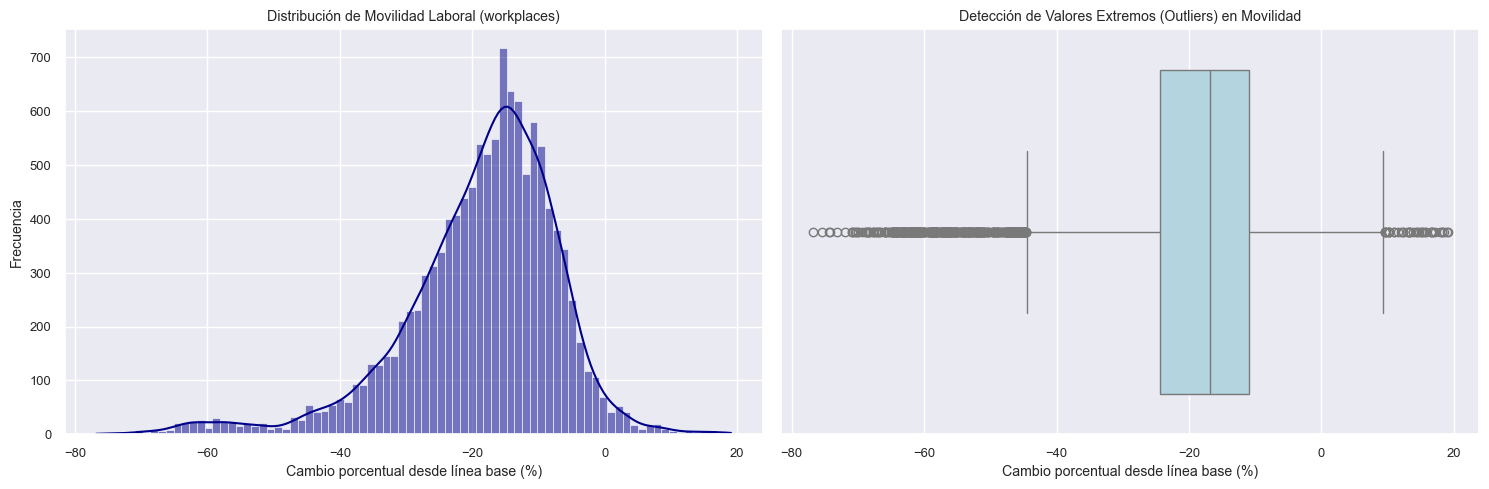

In [11]:
# Diagnóstico Visual de la Variable Dependiente (Workplaces)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df['workplaces'], kde=True, color='darkblue', ax=ax[0])
ax[0].set_title('Distribución de Movilidad Laboral (workplaces)')
ax[0].set_xlabel('Cambio porcentual desde línea base (%)')
ax[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df['workplaces'], color='lightblue', ax=ax[1])
ax[1].set_title('Detección de Valores Extremos (Outliers) en Movilidad')
ax[1].set_xlabel('Cambio porcentual desde línea base (%)')

plt.tight_layout()
plt.show()

Análisis de Valores Atípicos (Outliers) y Preservación de la Muestra:

El diagnóstico visual mediante diagramas de caja (Boxplots) y distribuciones de densidad revela la presencia de valores extremos en variables como workplaces, daily_cases y los indicadores de movilidad alternativa. Metodológicamente, se ha tomado la decisión estricta de no eliminar ni truncar estas observaciones.

Esto, ya que en el contexto de la crisis sanitaria global (COVID-19), estos outliers no representan errores de medición ni anomalías de digitación, sino que capturan empíricamente los shocks estructurales extremos inherentes a la pandemia (olas de contagio masivo y confinamientos totales). Su eliminación incurriría en un sesgo de selección y censuraría la varianza exacta que el modelo econométrico busca explicar.

### Análisis específico por variable




| Variable | Valores y Justificación Lógica |
| :--- | :--- |
| **`iso_code`** | **Valores:** 54 categorías únicas (Ej: DE-NW).<br>**Justificación:** Válido. Corresponde a los identificadores válidos. |
| **`retail_and_recreation...`** | **Valores:** Mín: -95.60 \| Máx: 74.60 \| Media: -16.44.<br>**Justificación:** Válido. El promedio negativo refleja directamente las restricciones al comercio no esencial durante la pandemia. |
| **`grocery_and_pharmacy...`** | **Valores:** Mín: -66.20 \| Máx: 83.60 \| Media: 5.12.<br>**Justificación:** Válido. Al ser recintos esenciales para el abastecimiento de comida y medicinas, es lógico que su promedio general sea positivo. |
| **`parks_percent...`** | **Valores:** Mín: -95.80 \| Máx: 631.00 \| Media: 49.68.<br>**Justificación:** Válido. Los peaks positivos masivos (631%) reflejan el aumento del uso de áreas verdes públicas en las ventanas de desconfinamiento. |
| **`transit_stations...`** | **Valores:** Mín: -88.60 \| Máx: 123.20 \| Media: -17.60.<br>**Justificación:** Válido. Media negativa congruente con la drástica caída en el uso del transporte público por cuarentenas y miedo al contagio. |
| **`workplaces_raw`** | **Valores:** Mín: -87.00 \| Máx: 6.60 \| Media: -25.00.<br>**Justificación:** Válido. Movilidad laboral sin procesar; la caída de hasta -87% evidencia el shock del teletrabajo y cierres forzosos. |
| **`residential_percent...`** | **Valores:** Mín: -3.80 \| Máx: 42.60 \| Media: 7.07.<br>**Justificación:** Válido. Tiene sentido que al reducirse la movilidad al trabajo o al comercio, el tiempo transcurrido en el hogar sube (promedio positivo). |
| **`trend`** | **Valores:** Mín: -80.07 \| Máx: 12.36 \| Media: -19.00.<br>**Justificación:** Válido. Tendencia de movilidad coherente con el resto de las caídas. |
| **`workplaces`** | **Valores:** Mín: -76.79 \| Máx: 19.06 \| Media: -18.67.<br>**Justificación:** Válido. . Sus promedios negativos capturan correctamente el efecto temporal de los confinamientos laborales. |
| **`Valor_Stringency_Index`** | **Valores:** Mín: 0.00 \| Máx: 93.52 \| Media: 27.49.<br>**Justificación:** Válido. El índice respeta perfectamente la escala un indice de 0 a 100, sin errores por fuera de ese rango. |
| **`Valor_GovernmentResponseIndex`** | **Valores:** Mín: 0.00 \| Máx: 81.31 \| Media: 30.64.<br>**Justificación:** Válido. Índice consolidado en márgenes lógicos de 0 a 100. |
| **`Valor_EconomicSupportIndex`** | **Valores:** Mín: 0.00 \| Máx: 100.00 \| Media: 30.96.<br>**Justificación:** Válido. Se mantiene entre el 0 y 100. |
| **`Valor_Containment_Health_index`** | **Valores:** Mín: 0.00 \| Máx: 85.42 \| Media: 30.59.<br>**Justificación:** Válido. Captura políticas de testeo y aislamiento dentro de su límite máximo teórico de 100. |
| **`workplace_closing`** | **Valores:** Mín: 0.00 \| Máx: 3.00 \| Media: 0.85.<br>**Justificación:** Válido. Corresponde exactamente a los 4 niveles categóricos (0, 1, 2, 3) de severidad del cierre de lugares de trabajo definidos en su metodología. |
| **`daily_cases`** | **Valores:** Mín: 0.00 \| Máx: 22,203.31 \| Media: 2,355.73.<br>**Justificación:** Válido. Es fundamental notar que el mínimo es 0, descartando "contagios negativos". El máximo refleja el el peak alcanzado. |
| **`week`** | **Valores:** Mín: 1.00 \| Máx: 140.00 \| Media: 70.50.<br>**Justificación:** Válido. Numeración secuencial de las semanas. |
| **`year`** | **Valores:** Mín: 2020.00 \| Máx: 2022.00 \| Media: 2020.97.<br>**Justificación:** Válido. Son los años más críticos de la crisis del COVID-19 en Europa y el mundo. |
| **`NAME`** | **Valores:** 86 categorías únicas (Ej: Berlín).<br>**Justificación:** Válido. Nombres legibles de las ciudades que componen el panel. |
| **`Population`** | **Valores:** Mín: 201.05 \| Máx: 10,274.88 \| Media: 745.47.<br>**Justificación:** Válido. Población registrada lógicamente sin valores nulos ni negativos, coherente con la demografía de esas 86 regiones. |
| **`agriculture`** | **Valores:** Mín: 0.00 \| Máx: 0.07 \| Media: 0.01.<br>**Justificación:** Válido. Refleja porcentajes del PIB regional (entre 0% y 7%), que son proporciones habituales para la economía europea. |
| **`industry`** | **Valores:** Mín: 0.04 \| Máx: 0.23 \| Media: 0.12.<br>**Justificación:** Válido. Peso industrial dentro de valores lógicos. |
| **`construction`** | **Valores:** Mín: 0.02 \| Máx: 0.15 \| Media: 0.05.<br>**Justificación:** Válido. Proporciones sectoriales que no exceden el límite de 1 (100%). |
| **`age_dependency`** | **Valores:** Mín: 0.52 \| Máx: 0.84 \| Media: 0.65.<br>**Justificación:** Válido. Ratios demográficos europeos estándar, demostrando que no hay errores de digitación en los censos utilizados. |
| **`old_age_dependency`** | **Valores:** Mín: 0.26 \| Máx: 0.49 \| Media: 0.32.<br>**Justificación:** Válido. Captura de forma fidedigna la alta tasa de envejecimiento del continente. |
| **`young_age_dependency`** | **Valores:** Mín: 0.24 \| Máx: 0.51 \| Media: 0.33.<br>**Justificación:** Válido. Cohorte juvenil en proporciones normales. |
| **`sex_ratio`** | **Valores:** Mín: 91.45 \| Máx: 115.75 \| Media: 106.71.<br>**Justificación:** Válido. Expresa la cantidad de hombres por cada 100 mujeres. |
| **`unemp`** | **Valores:** Mín: 3.00 \| Máx: 36.00 \| Media: 12.22.<br>**Justificación:** Válido. Tasa de desempleo expresada en porcentaje (0 a 100). |
| **`f_unemp`** | **Valores:** Mín: 0.04 \| Máx: 0.33 \| Media: 0.11.<br>**Justificación:** Válido. Expresado en proporción decimal, coincidente con la variable anterior. |
| **`m_unemp`** | **Valores:** Mín: 0.02 \| Máx: 0.43 \| Media: 0.12.<br>**Justificación:** Válido. Al igual que el desempleo femenino, está libre de valores negativos o mayores a 1. |
| **`foreigners`** | **Valores:** Mín: 2.00 \| Máx: 15.00 \| Media: 8.15.<br>**Justificación:** Válido. Porcentaje de población migrante dentro de márgenes lógicos . |
| **`country`** | **Valores:** 5 categorías únicas (DE, ES, FR, IT, SE).<br>**Justificación:** Válido. Confirma el espacio muestral de los cinco países definidos para el panel temporal. |

Se generan dummies de la variable country y year

In [12]:
# 1. Transformar 'country' en Variables Dummy (Matemáticas 0 y 1)
# drop_first=True elimina el primer país (Alemania 'DE') para evitar multicolinealidad perfecta
df = pd.get_dummies(df, columns=['country'], drop_first=True, dtype=int)

# Transformar 'year' en Variables Dummy
df['year'] = df['year'].astype(int).astype(str)
df = pd.get_dummies(df, columns=['year'], drop_first=True, dtype=int)

**Pregunta 2**

Ejecute un modelo Pooled OLS para estimar la relacion entre las restricciones gubernamentales de movilidad y la variacion en movilidad laboral. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

Correlación con la variable workplaces 

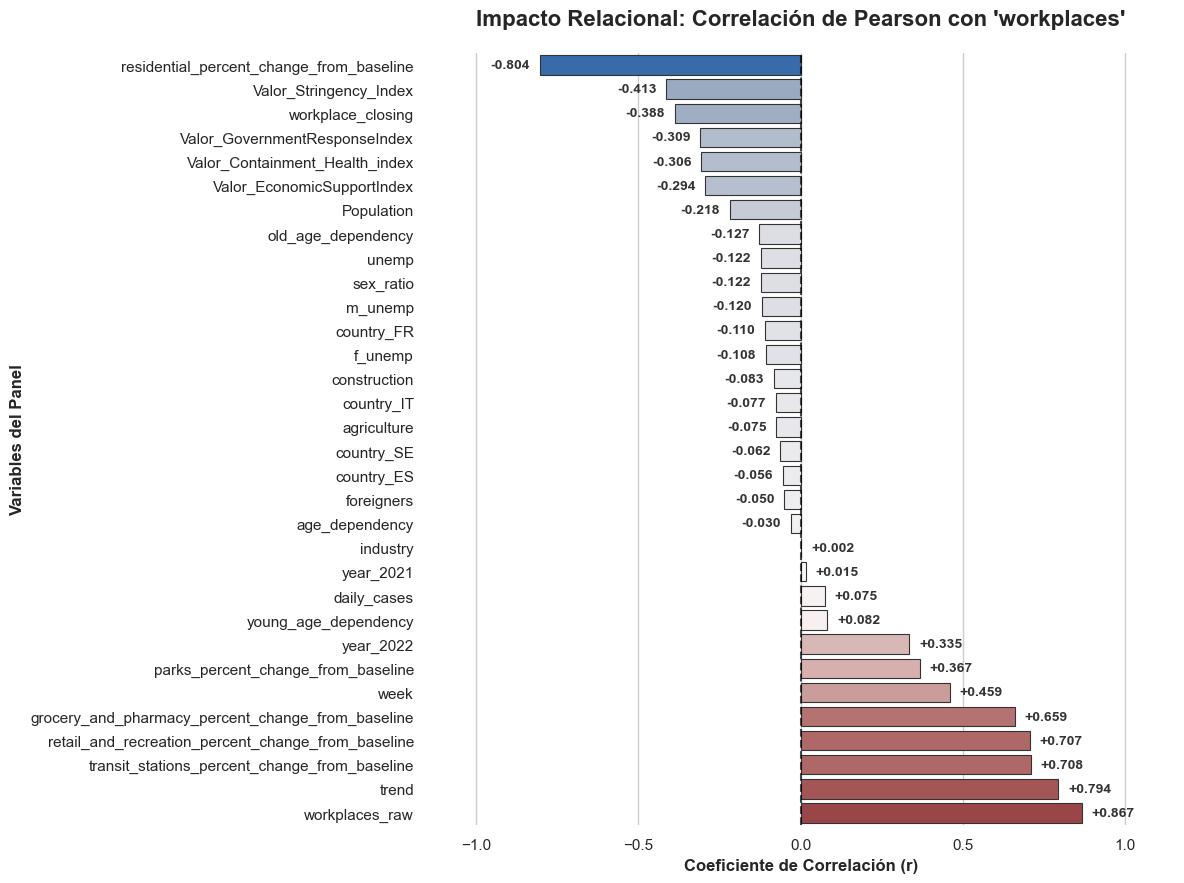

In [13]:

# CORRELACIÓN CON LA VARIABLE DEPENDIENTE (WORKPLACES)

import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos las variables numéricas (incluyendo floats e ints por seguridad)
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Calculamos la correlación de Pearson y aislamos nuestra Y ('workplaces')
correlaciones = df[columnas_numericas].corr()['workplaces'].drop('workplaces', errors='ignore')

# Ordenamos de la correlación más negativa a la más positiva
corr_ordenada = correlaciones.sort_values()

# Configuración visual del gráfico (Estilo minimalista)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 9))

# Creamos el gráfico de barras. 
# Usamos 'hue' y la paleta 'vlag' para mapear colores fríos (negativos) y cálidos (positivos)
ax = sns.barplot(
    x=corr_ordenada.values, 
    y=corr_ordenada.index, 
    hue=corr_ordenada.values, 
    palette="vlag", 
    legend=False,
    edgecolor=".2",
    linewidth=0.8
)

# Anotaciones de los valores numéricos exactos
for i, val in enumerate(corr_ordenada.values):
    # Desplazamiento dinámico para que el texto no pise la barra
    offset = 0.03 if val >= 0 else -0.03
    alineacion = 'left' if val >= 0 else 'right'
    
    # Formateamos el texto agregando un '+' explícito a los números positivos
    texto_valor = f"{val:+.3f}"
    
    ax.text(
        val + offset, i, 
        texto_valor, 
        va='center', 
        ha=alineacion, 
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

# Estética final de ejes y títulos (CORREGIDO A 'bold')
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.title("Impacto Relacional: Correlación de Pearson con 'workplaces'", 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coeficiente de Correlación (r)', fontsize=12, fontweight='bold')
plt.ylabel('Variables del Panel', fontsize=12, fontweight='bold')

# Ajustamos los límites de X para asegurar que los textos no se corten
plt.xlim(-1.15, 1.15) 

# Eliminamos los bordes superior y derecho de la caja para un look más limpio
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

**Matriz de correlación**


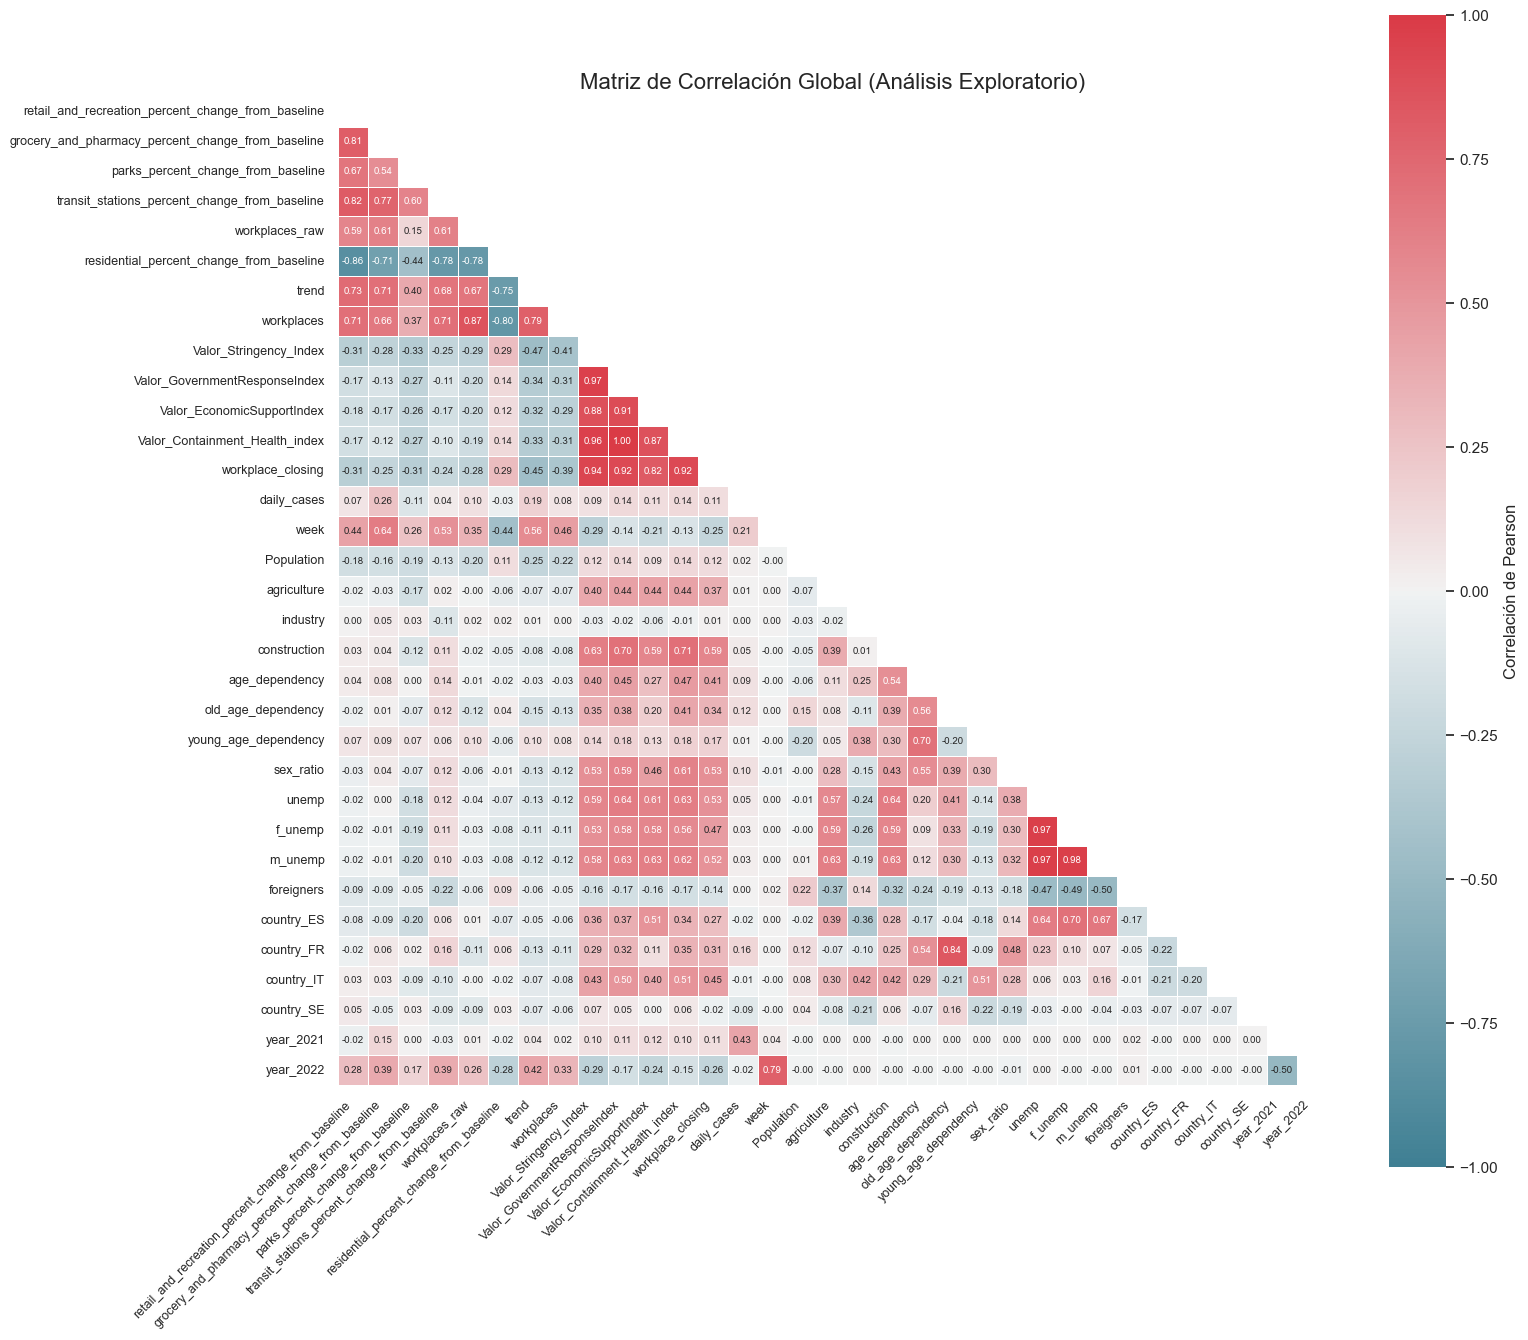

In [14]:
# Se seleccionan exclusivamente las variables numéricas
# (Para que .corr() no arroje error al intentar leer columnas de texto)
df_numerico = df.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación completa
corr = df_numerico.corr()

# Configuración visual
sns.set(style="white")
f, ax = plt.subplots(figsize=(16, 16)) # Lienzo más grande para que quepan todas
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Ocultar el triángulo superior para evitar duplicados
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dibujar el mapa de calor
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, 'label': 'Correlación de Pearson'},
    annot=True,            # Muestra los valores numéricos
    fmt=".2f",             # Dos decimales
    annot_kws={"size": 7}  
)

# Ajustes de legibilidad
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Matriz de Correlación Global (Análisis Exploratorio)', fontsize=16)
plt.tight_layout()
plt.show()

 Se observa que los índices Stringency, GovernmentResponse, Containment, EconomicsSupport y workplace_closing estaban correlacionados casi al 1, por lo tanto, se deberia elegir solo una para que represente la política del gobierno, se escoge Stringency.
 
 f_unamp, m_unamp y unamp también estan muy correlacionadas acercándose a 1, por lo que tambien se elige una de las tres donde la candidata principal en este caso sería unamp que engloba todo el desempleo.

 workplaces y workplaces_raw tambien presentan una alto valor (0.87) ya que se basan lo mismo, por lo tanto se elimina workplaces_raw y se conserva solo workplaces

Las variables que tienen que ver con la movilidad como lo son residential_percent_change_baseline, transit_stations_percent_change_baseline, grocery_and_pharmacy_percent_change_from_baseline, parks_percent_change_from_baseline, retail_and_recreation_percent_change_from_baseline tambien serán excluidas ya que fueron consecuencia de la cuarentena y serían redundantes, además presentan en su mayoria una alta correlacion entre ellas 

Para controlar los shocks comunes asociados a la evolución temporal de la pandemia sin saturar los grados de libertad del modelo base, se prescindió de dummies semanales week. En su lugar, se incorporó el indicador de tendencia continua "trend" y variables dummy anuales con "year".



A continuacion se ejecuta el VIF para las variables que siguen siendo candidatas

In [ ]:

#TEST DE MULTICOLINEALIDAD GLOBAL (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# 1. Armamos un set de datos amplio con TODAS las X potenciales.

variables_candidatas = [
    'Valor_Stringency_Index',
   #'workplace_closing',
    'daily_cases',
    'Population',  
    'agriculture', 
    'industry', 
    'construction',
    'old_age_dependency', 
    'young_age_dependency', 
    'age_dependency',
    'sex_ratio',
    'country_ES','country_FR','country_IT','country_SE', 'trend', 'year_2021', 'year_2022',
    'unemp'
]

# Creamos el DataFrame solo con las seleccionadas y eliminamos valores nulos (vital para el VIF)
X_vif_completo = df[variables_candidatas].dropna().copy()

# Agregamos la constante 
X_vif_completo = sm.add_constant(X_vif_completo)

#  Calculamos el VIF iterando sobre todas las columnas
vif_data = pd.DataFrame({
    "Variable": X_vif_completo.columns,
    "VIF": [variance_inflation_factor(X_vif_completo.values, i) for i in range(X_vif_completo.shape[1])]
})

#  Mostramos ordenado de mayor a menor (omitiendo la constante)
tabla_vif = vif_data[vif_data['Variable'] != 'const'].sort_values("VIF", ascending=False)
display(tabla_vif.round(2))

,Variable,VIF
9,age_dependency,1396.27
8,young_age_dependency,965.73
7,old_age_dependency,674.49
12,country_FR,11.47
13,country_IT,7.19
11,country_ES,6.44
18,unemp,4.78
1,workplace_closing,4.18
6,construction,3.56
10,sex_ratio,2.84


Se pueden observar que hay variabes con muy alto VIF por lo que se deben ir eliminando para evitar las redundancias. 
Con estos resultados iniciales se puede observar problemas de multicolinealidad, especialmente entre las variables demográficas. Dado que young_age_dependency y old_age_dependency son subcomponentes directos de la tasa de dependencia demográfica global, su inclusión simultánea genera redundancia.

Es por esto que se eliminará young_age_dependency y old_age_dependecy y se dejará age_dependency.

La variable trend será excluida de la especificación final de los modelos debido a que representa una tendencia temporal agregada del periodo analizado, capturando la evolución general del tiempo durante la pandemia. Si bien su inclusión incrementa considerablemente el ajuste estadístico del modelo, también absorbe gran parte de la variación temporal asociada a las restricciones gubernamentales y a la dinámica propia del COVID-19, dificultando la interpretación de las variables de interés. Además, trend no corresponde a una variable económica claramente definida, no representa una política pública específica, no constituye una característica estructural observable de las regiones y carece de una interpretación causal natural en relación con la movilidad laboral.


Se observará el efecto de esto y luego se continuará si es necesario.





In [16]:
#TEST DE MULTICOLINEALIDAD GLOBAL (VIF)


variables_candidatas = [
    'Valor_Stringency_Index',
    #'workplace_closing',
    'daily_cases',
    'Population',  
    'agriculture', 
    'industry', 
    'construction', 
    'age_dependency',
    'sex_ratio', 
    'country_ES',
    'country_FR',
    'country_IT',
    'country_SE',
    #'trend',
    #'year_2021', 
    #'year_2022',
    'unemp',
]

# Creamos el DataFrame solo con las seleccionadas y eliminamos valores nulos (vital para el VIF)
X_vif_completo = df[variables_candidatas].dropna().copy()

# 2. Agregamos la constante (Paso obligatorio para el cálculo matricial)
X_vif_completo = sm.add_constant(X_vif_completo)

# 3. Calculamos el VIF iterando sobre todas las columnas
vif_data = pd.DataFrame({
    "Variable": X_vif_completo.columns,
    "VIF": [variance_inflation_factor(X_vif_completo.values, i) for i in range(X_vif_completo.shape[1])]
})

# 4. Mostramos ordenado de mayor a menor (omitiendo la constante)
tabla_vif = vif_data[vif_data['Variable'] != 'const'].sort_values("VIF", ascending=False)
display(tabla_vif.round(2))

,Variable,VIF
9,country_ES,5.47
11,country_IT,5.39
10,country_FR,5.22
13,unemp,4.28
1,Valor_Stringency_Index,3.56
6,construction,3.39
7,age_dependency,2.78
8,sex_ratio,2.75
5,industry,1.84
4,agriculture,1.79



Estas eliminaciones tuvieron buenos efectos, logrando reducir el VIF de age_dependency a 2.78 y disminuyendo drásticamente la multicolinealidad general. Si bien algunas variables de control como las country muestran un VIF levemente superior a 5, este valor sigue encontrandose en un rango aceptable y no compromete la variable principal de estudio.




Para formar el panel de datos primero se ajusta la columna de fechas a un formato de tiempo. Luego, se establece la ciudad (CODE) y la fecha (date) como el índice principal. Se utilizo CODE ya que es un código alfanumérico, sin espacios ni caracteres especiales como los puede tener name o iso-code 

Para responder a la pregunta, el objetivo es aislar el impacto de las políticas gubernamentales sobre la movilidad laboral, controlando por todos los demás factores que también podrían haber dejado a la gente en sus hogares. Tras el análisis presentado anteriormente, el modelo final se compone de las siguientes variables:

| Variables | Justificación |
| :--- | :--- |
|**workplaces (Variable dependiente)** |Representa la variación porcentual de la movilidad hacia los lugares de trabajo respecto a la línea base|
|**Valor_Stringency_Index**| Indice continuo 0-100 que expresa directamente que expresa directamente la severidad de las restricciones gubernamentales de movilidad| 
|**Shock Sanitario (daily_cases)**| Las personas pueden dejar de ir al trabajo voluntariamente por el pánico a los contagios, que es de manera independientemente de lo que puede definir el gobierno|
|**Matriz Productiva (agriculture, industry, construction)**| Regiones con alta concentración agrícola o de construcción no pueden aplicar "teletrabajo" lo que influira en la variacion en los lugares de trabajo|
|**Estructura Demográfica (Population, age_dependency, sex_ratio)**| Las tasas de dependencia dictan la proporción real de la población que pertenece a la fuerza laboral activa|
|**Desempleo (unemp)**| La tasa de desempleo afecta estructuralmente la proporcion de personas que se movilizan al trabajo|
|**Paises (country_ES,country_IT, country_FR, country_SE)**| Controlan las diferencias culturales, legales y económicas propias de cada nación, usando a Alemania como punto de comparación.|


In [17]:
#           Definición de la estructura temporal-espacial del Panel (Set Index)


dfpanel = df.set_index(['CODE', 'date'])

In [18]:
#MODELO POOLED OLS (Mínimos Cuadrados Agrupados)


# Definimos nuestras variables finales seleccionadas
variables_finales = [
    'Valor_Stringency_Index',
 
    'daily_cases',       # Control: Shock Sanitario
    'Population',        # Control: Demografía
    'agriculture',       # Control: Matriz Productiva
    'industry',          
    'construction',      
    'age_dependency',    # Control: Dependencia demográfica 
    'sex_ratio',         # Control: Composición por sexo
    'country_ES',        # Control Geográfico: España
    'country_FR',        # Control Geográfico: Francia
    'country_IT',        # Control Geográfico: Italia
    'country_SE',        # Control Geográfico: Suecia
    #'trend',             # Control Temporal: Tendencia continua
    #'year_2021',         # Control Temporal: Año 2021
    #'year_2022'          # Control Temporal: Año 2022
    'unemp'
]

# Limpieza de datos nulos estrictamente en las columnas del modelo
datos_modelo = dfpanel[['workplaces'] + variables_finales].dropna()

y = datos_modelo['workplaces']
X = datos_modelo[variables_finales]

# Inclusión del Intercepto matemático (\beta_0)
X = sm.add_constant(X)

# Estimación del Modelo Pooled OLS 
# Utilizamos cov_type='robust' para blindar el modelo contra la heterocedasticidad
modelo_pooled = lmp.PooledOLS(y, X)
resultados_pooled = modelo_pooled.fit(cov_type='robust') 

# Despliegue de Resultados
print(resultados_pooled)
#print(resultados_pooled.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             workplaces   R-squared:                        0.3191
Estimator:                  PooledOLS   R-squared (Between):              0.6349
No. Observations:               12040   R-squared (Within):               0.2672
Date:                Mon, May 25 2026   R-squared (Overall):              0.3191
Time:                        20:49:34   Log-likelihood                -4.449e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      433.49
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(13,12026)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             285.56
                            

**Conclusiones del Modelo Pooled OLS (Nueva Especificación):**

Poder Explicativo del Modelo ($R^2$): El modelo logra explicar un 31.91% de la varianza total de la variación en la movilidad laboral ($R^2$ Overall). Desglosando este poder predictivo, el modelo es particularmente bueno para explicar las diferencias estructurales entre las distintas ciudades con un 63.49% ($R^2$ Between), pero explica en menor medida las variaciones que ocurren a través del tiempo dentro de cada ciudad, con un 26.72% ($R^2$ Within). 



**Efecto de las variables en la variación de la movilidad laboral:**

*Restricciones Gubernamentales (Valor_Stringency_Index):* Su efecto es negativo y altamente significativo (p-value < 0.001). Si el índice de rigurosidad aumenta en 1 punto (medidas más estrictas), se asocia con una fuerte disminución promedio de 0.3502 puntos porcentuales en la movilidad laboral.

*Tasa de Desempleo (unemp):* Resultó ser estadísticamente significativa (p-value = 0.0217). Un aumento de un 1% en la tasa de desempleo local reduce la variación de movilidad en 0.0534 puntos porcentuales, confirmando que a mayor desempleo, una menor proporción de la población se desplaza hacia lugares de trabajo.

*Controles Geográficos (Country):* Se utilizó a Alemania como país base de comparación. Las variables dummy para España, Francia, Italia y Suecia son positivas y significativas. Esto indica que, controlando por todas las demás variables, Italia por ejemplo tiene en promedio una variación de movilidad laboral 16.115 puntos porcentuales mayor que Alemania.

*Matriz Productiva (agriculture, industry, construction):* Tienen un impacto altamente significativo. Ciudades con un peso mayoritario en la industria experimentan una disminución relativa en su movilidad (-23.252 puntos), mientras que ciudades orientadas a la construcción ven un aumento en su movilidad (+29.371 puntos), posiblemente porque el rubro de la construcción es incompatible con el teletrabajo.

*Estructura Demográfica:* El aumento poblacional (Population) y la proporción de hombres (sex_ratio) empujan levemente la movilidad hacia la baja. Por otro lado, la tasa de dependencia (age_dependency) tiene un fuerte impacto positivo (+18.532) sobre la movilidad observada.

*Shock Sanitario (daily_cases):* Muestra un coeficiente significativo pero ínfimo (0.0005). Este valor, contraintuitivamente positivo, advierte la posible presencia de un sesgo por variable omitida (por ejemplo, al no incluir tendencias temporales o estacionales, los peaks de contagios pueden estar coincidiendo numéricamente con meses de mayor movilidad basal).

*Sobre la Constante*: La constante del modelo no es estadísticamente significativa (p-value=0.4893). Esto indica que no existe evidencia suficiente para afirmar que el intercepto difiere de cero. Dado que representa el valor esperado de movilidad para una ciudad en Alemania (país base) cuando todas las métricas son cero, su falta de significancia es matemáticamente correcta y no afecta la interpretación de nuestras variables de interés.



La constante del modelo no resulta estadísticamente significativa (p-value=0.6043) lo que esta indicando que no existe evidencia suficiente para afirmar que el intercepto difiere de cero una vez controladas las demás variables del modelo. Dado que la constante representa el valor esperado de la variación de movilidad laboral cuando los regresores toman valor cero, su falta de significancia no afecta la interpretación de las variables de interés. Metodológicamente, se mantiene el intercepto para evitar forzar la regresión por el origen y preservar la correcta estimación de los coeficientes.

**Pregunta 3**

Se continua con las variables seleccionadas previamente para la posterior comparación entre modelos. Se genera el modelo de efectos fijos a continuación.

In [19]:
modeloFE = lmp.PanelOLS(y, X, entity_effects=True, drop_absorbed=True)  # ✅
fe = modeloFE.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             workplaces   R-squared:                        0.2700
Estimator:                   PanelOLS   R-squared (Between):             -763.55
No. Observations:               12040   R-squared (Within):               0.2700
Date:                Mon, May 25 2026   R-squared (Overall):             -107.52
Time:                        20:49:34   Log-likelihood                -4.399e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      736.37
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                 F(6,11948)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             521.47
                            

**Conclusiones del Modelo de Efectos Fijos (FE):**

Para el modelo de efectos fijos se tomó la variación de movilidad laboral (workplaces) como variable dependiente. La librería identificó y absorbió automáticamente las variables que eran constantes en el tiempo para cada ciudad (como las dummies de los países, agriculture y construction), dejando únicamente aquellas que presentaban fluctuaciones temporales.

***Las conclusiones principales son:***

Poder Explicativo y Validez del Modelo: El modelo logra explicar un 27.00% de la varianza total de la movilidad a lo largo del tiempo dentro de cada ciudad ($R^2$ Within). Los valores negativos en el $R^2$ Overall y Between son comunes matemáticamente en estimaciones de Efectos Fijos con datos muy heterogéneos, ya que el modelo se optimiza exclusivamente para capturar la variabilidad temporal. 

***Efecto de las variables en la movilidad temporal***

Dado que todas las variables retenidas son estadísticamente significativas ($p-value < 0.001$), se concluye lo siguiente:

*Restricciones Gubernamentales (Valor_Stringency_Index)*:  Un aumento temporal de 1 punto en el índice de rigurosidad reduce directamente la movilidad laboral en 0.3509 puntos porcentuales.

*Tasa de Desempleo (unemp)*: Al analizar la variación dentro de la ciudad, un aumento temporal en la tasa de desempleo se asocia a un aumento temporal en la movilidad de 0.6381 puntos (pasa de negativo en OLS a positivo en FE), en ese sentido los periodos de mayor desempleo en una ciudad pueden forzar a la población a salir de sus casas para buscar trabajo activamente de forma presencial o incurrir en informalidad.

*Variables demograficas (Population,  sex_ratio)*: Aunque pueden pensarse como estáticas, en esta base de datos presentaron variación temporal. Aumentos de población  en el tiempo empujan levemente la movilidad a la baja, mientras que los cambios en la proporción por sexo la empujan al alza.

*Shock Sanitario (daily_cases)*: Se mantiene altamente significativo y con coeficiente positivo, pero con un impacto que se hace notar al tener miles de contagios lo cual como se señalo antes es contraintuitivo.


*Industry:* La concentración industrial cambiará muy poco en espacios de tiempo pequeños, como su variación temporal es tan pequeña, ese -257.83 como resultado puede ser esperado matemáticamente en Efectos Fijos al tratarse de una variable estructural de lento cambio, por lo que su interpretación económica directa debe tomarse con precaución.

**Pregunta 4**


Ejecute un modelo de efectos aleatorios para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. 

In [20]:
modeloRE=lmp.RandomEffects(y,X)
re=modeloRE.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2716
Estimator:              RandomEffects   R-squared (Between):              0.6284
No. Observations:               12040   R-squared (Within):               0.2673
Date:                Mon, May 25 2026   R-squared (Overall):              0.3183
Time:                        20:49:35   Log-likelihood                -4.405e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      345.00
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(13,12026)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             210.74
                            

**Conclusiones del Modelo de Efectos Aleatorios (RE):**

Para el modelo de efectos aleatorios se tomó la variación en la movilidad laboral (workplaces) como variable dependiente, utilizando el mismo conjunto de variables independientes que en los modelos anteriores.

***Las conclusiones principales son:***

Poder Explicativo del Modelo ($R^2$): El modelo logra explicar un 31.83% de la varianza total de la movilidad laboral en el contexto general ($R^2$ Overall). De manera similar al Pooled OLS, logra explicar de muy buena forma (en un 62.84%) la varianza estructural entre las distintas ciudades ($R^2$ Between), y explica de manera moderada (en un 26.73%) los cambios de variabilidad a lo largo del tiempo ($R^2$ Within).

***Efecto de las variables en la variación de la movilidad laboral:***

*Restricciones Gubernamentales (Valor_Stringency_Index)*: Mantiene un efecto negativo, si el indice aumenta en 1 punto, se asocia con una disminución promedio de 0.3507 puntos porcentuales en la movilidad laboral.

*Matriz Productiva (industry):* Tener una alta dependencia en el sector industrial reduce la expectativa de movilidad laboral en 19.571 puntos. (Los sectores de agricultura y construcción perdieron significancia estadística en este modelo).

*Estructura Demográfica:* Un aumento en la tasa de dependencia demográfica (age_dependency) aumenta la movilidad base en 15.589 puntos.
Por el contrario, ciudades con mayor volumen de población (Population) ven disminuida levemente su movilidad en 0.0016 puntos por unidad poblacional.

*Controles Geográficos (Países):* Utilizando a Alemania como base, todas las demás naciones analizadas incrementan la expectativa de movilidad: España en 13.281 puntos, Francia en 9.128 puntos, Italia en 15.179 puntos y Suecia en 6.011 puntos. Esto revela diferencias culturales o macroeconómicas persistentes entre países frente a la pandemia.

*Shock Sanitario (daily_cases)*: Se mantiene altamente significativo, pero con un impacto que como se señalo anteriormente se hace notar cuando hay miles de casos diarios.

*Variables no significativas:* Bajo la estructura de Efectos Aleatorios, la tasa de desempleo (unemp), la proporción de hombres (sex_ratio), y sectores como agriculture y construction demostraron tener un impacto no significativo ($p-values > 0.05$) en la movilidad laboral.


**Pregunta 5**

*Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?*

Se compararan los tres modelos a traves de la tabla presentada a continuación, junto con la aplicación del test de Hausman

In [21]:

# Comparar los tres modelos en una sola tabla
print("─── Comparación de Modelos Panel ───")
print(lmp.compare({'Pooled OLS': resultados_pooled, 'Fixed Effects': fe, 'Random Effects': re}))
def hausman(fe, re, verbose=True):
    common = fe.params.index.intersection(re.params.index)
    
    # Filtrar constante 
    common = [c for c in common if c.lower() != 'const']

    # Es mejor restar FE - RE para mantener consistencia
    b_diff = fe.params[common] - re.params[common] 
    

    v_diff = fe.cov.loc[common, common] - re.cov.loc[common, common]

    if b_diff.isnull().any() or v_diff.isnull().values.any():
        raise ValueError("NaNs en b_diff o v_diff")

    cond = np.linalg.cond(v_diff)
    if cond > 1e12:
        if verbose:
            print(f"⚠️ Matriz casi singular (condición = {cond:.2e}), usando pseudoinversa")
        v_inv = np.linalg.pinv(v_diff)
    else:
        v_inv = np.linalg.inv(v_diff)

    W = float(b_diff.T @ v_inv @ b_diff)
    df = len(common)
    pval = stats.chi2.sf(W, df)

    if verbose:
        decision = "✅ Rechazar H0 → usar FE" if pval < 0.05 else "✅ No se rechaza H0 → usar RE"
        print(f"Hausman Test: χ²({df}) = {W:.2f}, p-value = {pval:.4f} → {decision}")

    return W, df, pval

hausman(fe, re)


─── Comparación de Modelos Panel ───
                             Model Comparison                             
                               Pooled OLS  Fixed Effects    Random Effects
--------------------------------------------------------------------------
Dep. Variable                  workplaces     workplaces        workplaces
Estimator                       PooledOLS       PanelOLS     RandomEffects
No. Observations                    12040          12040             12040
Cov. Est.                          Robust         Robust            Robust
R-squared                          0.3191         0.2700            0.2716
R-Squared (Within)                 0.2672         0.2700            0.2673
R-Squared (Between)                0.6349        -763.55            0.6284
R-Squared (Overall)                0.3191        -107.52            0.3183
F-statistic                        433.49         736.37            345.00
P-value (F-stat)                   0.0000         0.0000       

(133.4036951435202, 6, np.float64(2.4661611563841492e-26))

Existen diferencias en los resultados de los tres modelos debido a que cada uno hace supuestos distintos sobre la naturaleza de los datos:

El modelo Pooled OLS es una regresión simple que ignora por completo la estructura de panel, asumiendo que todas las observaciones son independientes y omitiendo el componente temporal e individual.

El modelo de Efectos Fijos (FE) considera la estructura de panel y asume que existen efectos inobservados propios y constantes para cada ciudad (como su cultura, geografía o infraestructura) que sí están correlacionados con las variables explicativas. Por ende, aísla estos efectos para estimar puramente el impacto de la variación temporal.

El modelo de Efectos Aleatorios (RE) supone que esos efectos inobservados de cada ciudad son simplemente aleatorios y que no tienen relación (no están correlacionados) con las variables explicativas.

*Conclusiones de la selección de modelo:*

Descarte de OLS: El modelo Pooled OLS se descarta porque ignora la estructura longitudinal de los datos y asume ingenuamente que todas las ciudades son idénticas en su comportamiento basal.


**Test de Hausman**

Para decidir matemáticamente entre Efectos Fijos y Efectos Aleatorios, se aplica el Test de Hausman. El resultado obtenido es contundente: p-value = 0.0000 → Rechazar H0. Al rechazar la hipótesis nula, se concluye que los efectos no observados si están correlacionados con los regresores. Por lo tanto, el modelo de Efectos Aleatorios entrega estimadores inconsistentes y el modelo que se debería utilizar es el de Efectos Fijos.


Modelo FE: El modelo de Efectos Fijos arrojó estimadores altamente significativos (todos con p-value < 0.001) y un $R^2$ Within robusto del 27.00%. Por lo tanto, repondiendo a la pregunta de investigación, se concluye estadísticamente que las políticas públicas tienen un efecto causal y directo en el comportamiento de la población, controlando por toda la heterogeneidad inobservada de cada ciudad, un aumento de 1 punto en el índice de restricciones gubernamentales (Valor_Stringency_Index) genera una caída de 0.3509 puntos porcentuales en la movilidad laboral. Este impacto resulta ser el mecanismo para reducir la movilidad, muy por encima del confinamiento voluntario generado por el pánico a los contagios diarios (daily_cases). 





**Pregunta 6**

Ejecute un modelo de efectos aleatorios correlacionados (CRE) para estimar la misma relacion anterior. Seleccione las variables independientes a incluir en el modelo final e interprete su significado. Es este modelo adecuado, dada la data disponible, para modelar el componente no observado?

In [22]:
# PREGUNTA 6: MODELO DE EFECTOS ALEATORIOS CORRELACIONADOS (CRE / MUNDLAK)

import statsmodels.api as sm
from linearmodels.panel import RandomEffects
import pandas as pd

# 1. Variables explicativas dinámicas (Time-Varying): Todas las que fluctúan en el tiempo
X_dinamicas = [
    'Valor_Stringency_Index', 
    'daily_cases', 
    'unemp', 
    'Population', 
    'sex_ratio'
]

# 2. Variables explicativas de control estructural (Time-Invariant): Las constantes
X_estaticas = [
    'agriculture', 'industry', 'construction', 'age_dependency',
    'country_ES', 'country_FR', 'country_IT', 'country_SE'
]

# 3. Usamos DFPANEL (vital para que funcione) para calcular las medias por ciudad (level=0)
Xm = dfpanel.groupby(level=0)[X_dinamicas].transform('mean')
Xm.columns = ['mean_' + col for col in Xm.columns]

# 4. Unimos la tabla de medias al dfpanel
dfpanel_cre = pd.concat([dfpanel, Xm], axis=1)

# 5. Definimos el conjunto final de regresores
variables_finales_cre = X_dinamicas + X_estaticas + list(Xm.columns)

# Limpieza de nulos
datos_modelo_cre = dfpanel_cre[['workplaces'] + variables_finales_cre].dropna()

y_cre = datos_modelo_cre['workplaces']
X_cre = datos_modelo_cre[variables_finales_cre]

# 6. Añadimos constante
X_cre = sm.add_constant(X_cre)

# 7. Estimación del Modelo CRE
cre_model = RandomEffects(y_cre, X_cre, check_rank=False)
cre_res = cre_model.fit(cov_type='robust')

# Despliegue de resultados
print(cre_res)


                        RandomEffects Estimation Summary                        
Dep. Variable:             workplaces   R-squared:                        0.2739
Estimator:              RandomEffects   R-squared (Between):              0.6345
No. Observations:               12040   R-squared (Within):               0.2699
Date:                Mon, May 25 2026   R-squared (Overall):              0.3213
Time:                        20:49:36   Log-likelihood                -4.403e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      251.97
Entities:                          86   P-value                           0.0000
Avg Obs:                       140.00   Distribution:                F(18,12021)
Min Obs:                       140.00                                           
Max Obs:                       140.00   F-statistic (robust):             156.26
                            

Conclusiones del Modelo de Efectos Aleatorios Correlacionados (CRE):

Para el modelo CRE se tomó la variación de movilidad laboral (workplaces) como variable dependiente. Como variables independientes se utilizaron las mismas que en los modelos anteriores, con la diferencia metodológica de que se le concatenaron los promedios temporales (mean_) de cada variable que fluctuaba en el tiempo para cada ciudad.

Las conclusiones principales son:

Poder Explicativo del Modelo ($R^2$): El modelo logra explicar un 32.13% de la varianza total de la movilidad laboral en el contexto general ($R^2$ Overall). Logra explicar de buena forma la varianza estructural entre distintas ciudades con un 63.45% ($R^2$ Between), y explica de manera moderada los cambios temporales dentro de cada ciudad con un 26.99% ($R^2$ Within). Estos valores son muy similares a los obtenidos en los modelos anteriores, demostrando la robustez de la base de datos.

Efectos temporales dentro de cada ciudad (Variables Originales):

Restricciones Gubernamentales (Valor_Stringency_Index): Se mantiene como el factor más robusto de todo el estudio. El modelo aisla su efecto puro, concluyendo que al aumentar la severidad en 1 punto, la movilidad laboral de la ciudad cae temporalmente en 0.3512 puntos porcentuales (p-value = 0.0000).
Tasa de desempleo (unemp): Refleja la variación temporal. Un aumento en la tasa de desempleo a lo largo del tiempo dentro de la misma ciudad se asocia a un alza de 0.6407 en la movilidad laboral, posiblemente por el aumento en la búsqueda presencial de empleo.
Población y Sexo: Un aumento temporal en la población (Population) muestra una leve disminución temporal en la movilidad (-0.0946), mientras que cambios en la demografía por sexo (sex_ratio) aumentan la movilidad (2.2113).
Shock Sanitario (daily_cases): Se mantiene marginalmente positivo e ínfimo (0.0005).
Efectos estructurales constantes (Matriz Productiva y Demografía Estática):

Al igual que en Efectos Aleatorios, las ciudades con alta dependencia en la industria (industry) presentan una movilidad base 23.857 puntos menor que el resto (p-value = 0.0157).
Las ciudades con altas tasas de dependencia demográfica (age_dependency) muestran una movilidad base mayor en 18.021 puntos.
Los rubros de agriculture y construction resultaron no ser estadísticamente significativos.
Efectos de la media de las variables para captar las diferencias entre ciudades (mean_):

Media de desempleo (mean_unemp): Ciudades que en promedio tienen un nivel de desempleo 1 punto mayor que otras, experimentan una movilidad estructural 0.7040 puntos menor a lo largo de toda la pandemia (p-value = 0.0029). Nota metodológica: Esto resuelve la paradoja entre el modelo Pooled OLS y Efectos Fijos, demostrando que el desempleo crónico baja la movilidad general, pero los shocks temporales de desempleo la suben temporalmente.
Media de Población (mean_Population): Las ciudades que son históricamente más pobladas tienen, en promedio, 0.0930 puntos porcentuales más de movilidad que las ciudades más pequeñas.
Media de Sexo (mean_sex_ratio): Tener una proporción histórica promedio mayor reduce la movilidad estructural en 2.4411 puntos porcentuales.

**Pregunta 7**

Usando sus respuestas anteriores, que modelo prefiere? que se puede inferir en general respecto del efecto de las restricciones gubernamentales sobre la movilidad laboral?

A la hora de elegir el mejor modelo, la decisión se basa en las pruebas que fuimos construyendo paso a paso.

Primero, descartamos el modelo Pooled OLS porque es demasiado básico: asume que todas las ciudades se comportan igual e ignora por completo la identidad de cada una (cosa que el F-test nos demostró que era un error).

Luego comparamos Efectos Fijos (FE) y Efectos Aleatorios (RE) usando el Test de Hausman. El resultado fue súper claro (un p-value de 0.0000), lo que nos confirma empíricamente que las características ocultas de cada ciudad (su cultura de trabajo, su geografía, etc.) sí están fuertemente relacionadas con nuestras variables. Por ende, Efectos Fijos es matemáticamente superior a Efectos Aleatorios.

Sin embargo, el modelo que prefiero y considero más completo es el de Efectos Aleatorios Correlacionados (CRE). Elegir este modelo es la mejor decisión porque nos da lo mejor de ambos, logrando aislar el efecto puro a lo largo del tiempo sin sesgos (exactamente igual que Efectos Fijos), pero además nos permite ver el impacto de las variables que nunca cambian (como la industria o el país), algo que Efectos Fijos omite.

Tomando todo esto en cuenta, y basándonos en el modelo CRE, podemos inferir causalmente que las restricciones gubernamentales tienen un efecto directo y fuertemente negativo sobre la movilidad laboral. Al limpiar todo el ruido estadístico, vimos que cada vez que el gobierno aumenta en 1 punto su nivel de rigurosidad, la movilidad hacia los trabajos se contrae en 0.35 puntos porcentuales. Esto demuestra que las políticas públicas de encierro son efectivas.

**Pregunta 8**

Control Sintetico: Es posible que sus resultados anteriores tengan sesgo dado que la movilidad laboral y las restricciones son parte de un fenomeno dinamico en el tiempo. Utilice el notebook SynthControl.ipynb para estimar el efecto causal de las restricciones gubernamentales y la movilidad para una ciudad de su eleccion, usando control sintetico (viendo las fechas semanales, deben elegir el periodo de tratamiento e indentificar los controles potenciales para la ciudad elegida, que no puede ser Zaragoza). Defina las variables para calcular el control sintetico y discuta sus resultados (instalar libreria pysyncon)


**Análisis previo:** Para este ejercicio, se seleccionó la ciudad de Francia con código FR008C que corresponde a NIZA. Francia tuvo fuertes variaciones en sus políticas de movilidad durante la pandemia. 

In [23]:
import numpy as np
import pandas as pd
from pysyncon import Dataprep, Synth, AugSynth, PenalizedSynth
from pysyncon.utils import PlaceboTest
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

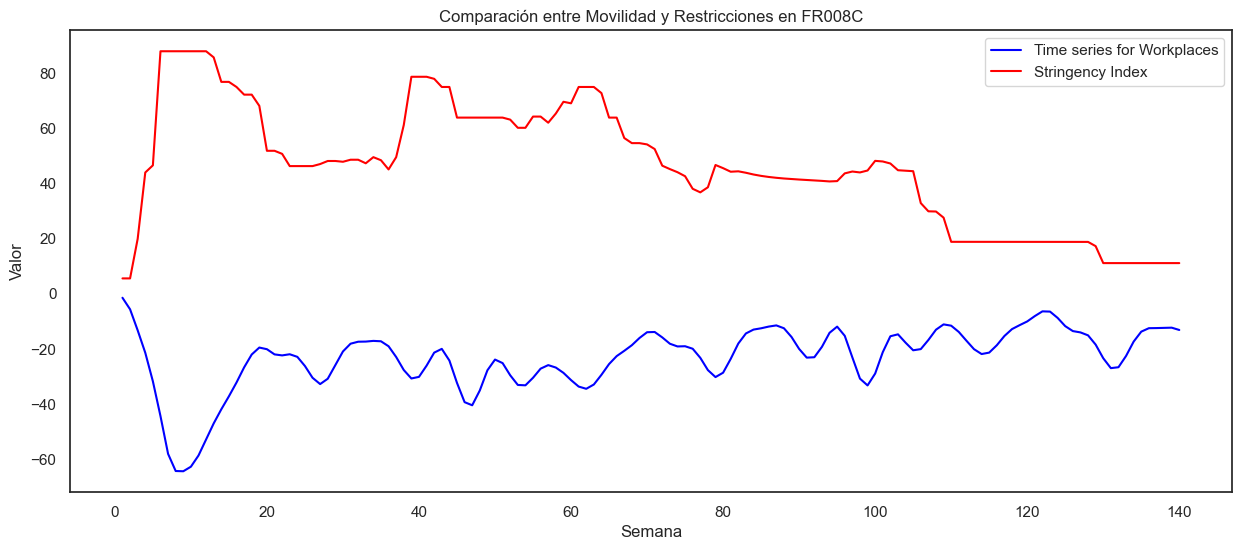

In [24]:
# Filtra los datos solo para la ciudad elegida
francia_data = df[df['CODE'] == 'FR008C']

# Configura el tamaño del gráfico
plt.figure(figsize=(15, 6))

# Grafica la serie temporal 'workplaces' para FR008C
plt.plot(francia_data['week'], francia_data['workplaces'], label='Time series for Workplaces', color='blue')

# Grafica la serie temporal de las restricciones para FR008C
plt.plot(francia_data['week'], francia_data['Valor_Stringency_Index'], label='Stringency Index', color='red')

# Configura etiquetas y leyenda
plt.xlabel('Semana')
plt.ylabel('Valor')
plt.title('Comparación entre Movilidad y Restricciones en FR008C')
plt.legend()

# Muestra el gráfico
plt.show()

In [25]:


df = pd.read_csv('dataset_prueba.csv')
city_data = df[df['CODE'] == 'FR008C'].sort_values('week')
pd.set_option('display.max_rows', None)
print("Historial de restricciones para FR008C:")
print(city_data[['week', 'Valor_Stringency_Index']].to_string(index=False))

pd.reset_option('display.max_rows')

Historial de restricciones para FR008C:
 week  Valor_Stringency_Index
    1                   5.560
    2                   5.560
    3                  19.908
    4                  43.980
    5                  46.572
    6                  87.960
    7                  87.960
    8                  87.960
    9                  87.960
   10                  87.960
   11                  87.960
   12                  87.960
   13                  85.738
   14                  76.850
   15                  76.850
   16                  75.000
   17                  72.220
   18                  72.220
   19                  68.146
   20                  51.850
   21                  51.850
   22                  50.740
   23                  46.300
   24                  46.300
   25                  46.300
   26                  46.300
   27                  47.040
   28                  48.150
   29                  48.150
   30                  47.870
   31                  48.610


In [26]:

#Cargar los datos
df = pd.read_csv('dataset_prueba.csv')

#Filtrar solo las ciudades de Francia
df_fr = df[df['country'] == 'FR']

#Seleccionamos la ciudad FR008C y ordenamos cronológicamente por semana
city_data = df_fr[df_fr['CODE'] == 'FR008C'].sort_values('week')

#Calculamos la diferencia del índice de restricciones de una semana a otra
# Un valor negativo significa que las restricciones bajaron 
diffs = city_data['Valor_Stringency_Index'].diff()

#Filtramos solo aquellas semanas donde hubo una caída drástica (mayor a 10)

caidas_drasticas = city_data[diffs < -10]

print("Semanas con caídas drásticas en las restricciones para FR008C:")
print(caidas_drasticas[['week', 'Valor_Stringency_Index']])

Semanas con caídas drásticas en las restricciones para FR008C:
      week  Valor_Stringency_Index
7719    20                  51.850
7744    45                  63.890
7805   106                  32.872


Al observar los datos, notamos que en la *semana 106* el índice de restricciones gubernamentales (Valor_Stringency_Index) cae de 44.45 a 32.8, marcando una fuerte liberación de las restricciones.

In [27]:
municipios_control = [municipio for municipio in df['CODE'].unique() if not str(municipio).startswith("FR")]

dataprep = Dataprep(
    foo=df,
    predictors=[
         'Population',
         'agriculture',
         'industry',
         'construction',
         'age_dependency',
         'sex_ratio',
         'unemp',
    ],
    predictors_op="mean",
    time_predictors_prior=range(1, 106),
    special_predictors=[
        ('daily_cases', range(1, 106), 'mean'),
    ],
    dependent="workplaces",
    unit_variable="CODE",
    time_variable="week",
    treatment_identifier='FR008C',
    controls_identifier=municipios_control,
    time_optimize_ssr=range(1, 106),
)

In [28]:
pen = PenalizedSynth()
pen.fit(dataprep, lambda_=0.01)

In [29]:
print(pen.weights().to_string())
print(pen.weights())

DE001C    0.000
DE007C    0.000
DE025C    0.000
DE033C    0.000
DE081C    0.000
DE003C    0.000
DE014C    0.000
DE031C    0.000
DE012C    0.000
DE005C    0.000
DE019C    0.000
DE091C    0.000
DE002C    0.000
DE040C    0.000
DE013C    0.000
DE085C    0.000
DE004C    0.000
DE006C    0.000
DE010C    0.000
DE011C    0.000
DE015C    0.000
DE016C    0.000
DE032C    0.000
DE034C    0.000
DE080C    0.000
DE082C    0.000
DE083C    0.000
DE086C    0.000
DE087C    0.000
DE088C    0.000
DE124C    0.000
DE036C    0.000
DE089C    0.000
DE008C    0.000
DE009C    0.000
DE084C    0.000
DE017C    0.000
DE018C    0.000
DE030C    0.000
ES021C    0.000
ES060C    0.000
ES002C    0.000
ES019C    0.165
ES025C    0.422
ES062C    0.000
ES020C    0.000
ES008C    0.000
ES059C    0.000
ES010C    0.000
ES006C    0.000
ES022C    0.000
ES004C    0.000
ES003C    0.000
ES012C    0.000
ES005C    0.000
IT004C    0.000
IT002C    0.000
IT011C    0.000
IT012C    0.000
IT027C    0.000
IT006C    0.413
IT009C    0.000
IT007C  

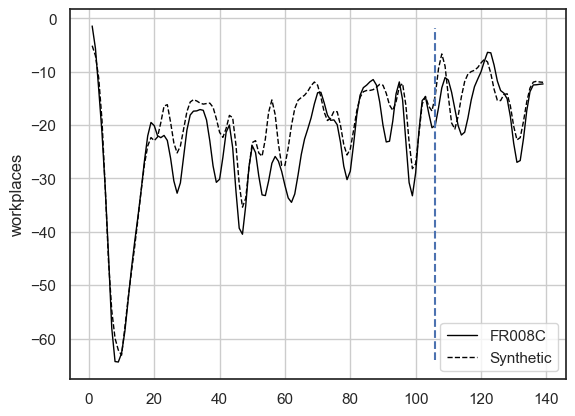

In [30]:
pen.path_plot(time_period=range(1, 140), treatment_time=106)

In [31]:
pen.summary()

,treated,synthetic,sample mean
Population,462.846,468.677,673.403
agriculture,0.005,0.008,0.007
industry,0.064,0.104,0.117
construction,0.077,0.071,0.051
age_dependency,0.837,0.721,0.636
sex_ratio,113.725,112.659,105.812
unemp,20.000,15.345,11.338
special.1.daily_cases,4178.450,2800.678,2625.944


In [32]:
synth = Synth()
synth.fit(dataprep=dataprep, optim_method="Nelder-Mead", optim_initial="ols")

DE001C    0.000
DE007C    0.000
DE025C    0.000
DE033C    0.000
DE081C    0.000
DE003C    0.000
DE014C    0.000
DE031C    0.000
DE012C    0.000
DE005C    0.000
DE019C    0.000
DE091C    0.000
DE002C    0.000
DE040C    0.000
DE013C    0.000
DE085C    0.000
DE004C    0.000
DE006C    0.000
DE010C    0.000
DE011C    0.000
DE015C    0.000
DE016C    0.000
DE032C    0.000
DE034C    0.000
DE080C    0.000
DE082C    0.000
DE083C    0.000
DE086C    0.000
DE087C    0.000
DE088C    0.000
DE124C    0.000
DE036C    0.000
DE089C    0.000
DE008C    0.000
DE009C    0.000
DE084C    0.000
DE017C    0.000
DE018C    0.000
DE030C    0.000
ES021C    0.000
ES060C    0.000
ES002C    0.000
ES019C    0.426
ES025C    0.000
ES062C    0.000
ES020C    0.000
ES008C    0.000
ES059C    0.000
ES010C    0.000
ES006C    0.000
ES022C    0.000
ES004C    0.000
ES003C    0.000
ES012C    0.000
ES005C    0.000
IT004C    0.000
IT002C    0.000
IT011C    0.000
IT012C    0.000
IT027C    0.000
IT006C    0.574
IT009C    0.000
IT007C  

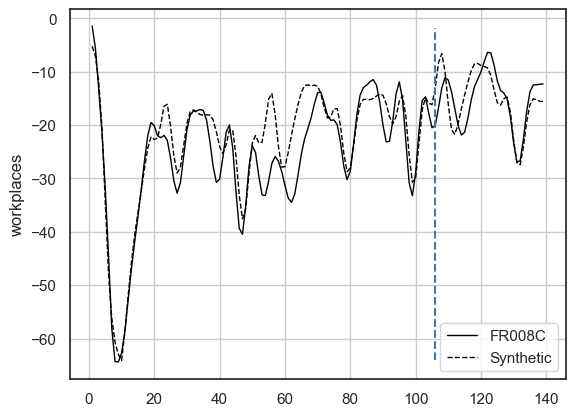

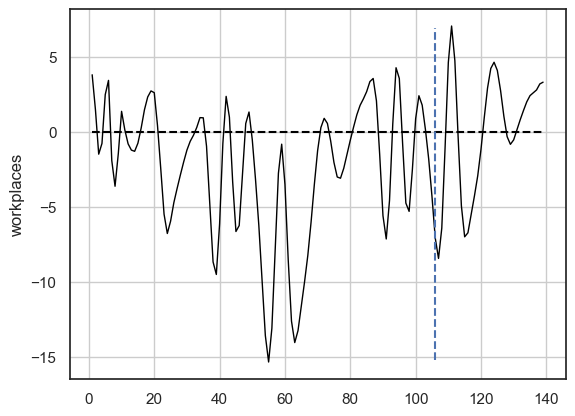

,V,treated,synthetic,sample mean
Population,0.208,462.846,663.105,673.403
agriculture,0.002,0.005,0.009,0.007
industry,0.036,0.064,0.139,0.117
construction,0.024,0.077,0.084,0.051
age_dependency,0.125,0.837,0.736,0.636
sex_ratio,0.008,113.725,110.249,105.812
unemp,0.466,20.000,18.234,11.338
special.1.daily_cases,0.132,4178.450,2800.934,2625.944


In [33]:
print(synth.weights().to_string())
print(synth.weights())
synth.path_plot(time_period=range(1, 140), treatment_time=106)
synth.gaps_plot(time_period=range(1, 140), treatment_time=106)
synth.summary()

In [34]:
augsynth = AugSynth()
augsynth.fit(dataprep=dataprep)

In [35]:
print(augsynth.weights())

DE001C   -1.537
DE007C   -0.121
DE025C    2.436
DE033C    0.294
DE081C    0.070
          ...  
IT005C    0.649
IT010C    0.582
IT064C   -1.191
SE001C    0.419
SE003C   -1.213
Name: weights, Length: 71, dtype: float64


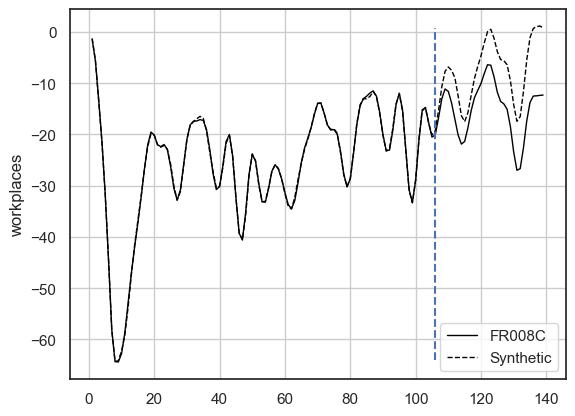

In [36]:
augsynth.path_plot(time_period=range(1, 140), treatment_time=106)

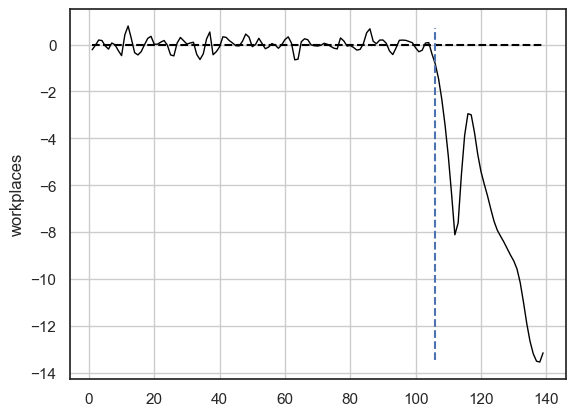

In [37]:
augsynth.gaps_plot(time_period=range(1, 140), treatment_time=106)

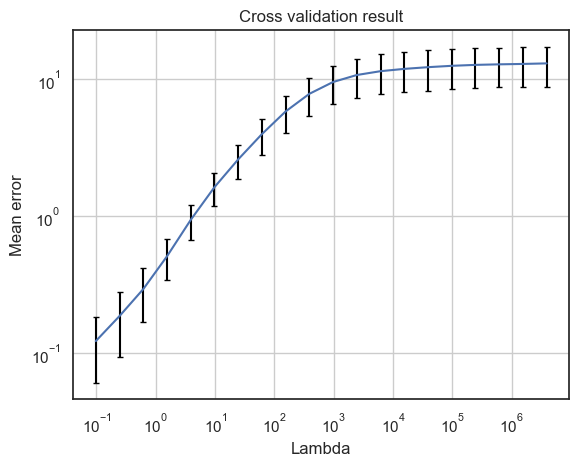

In [38]:
augsynth.cv_result.plot()

In [39]:
augsynth.summary()

,treated,synthetic,sample mean
Population,462.846,463.457,673.403
agriculture,0.005,0.005,0.007
industry,0.064,0.064,0.117
construction,0.077,0.077,0.051
age_dependency,0.837,0.837,0.636
sex_ratio,113.725,113.721,105.812
unemp,20.000,19.904,11.338
special.1.daily_cases,4178.450,4169.611,2625.944


 Descarte de los modelos Penalizado y Tradicional:

Al evaluar los métodos de Control Sintético Penalizado y Tradicional, notamos que no hacían un buen trabajo. Como se ve en las tablas de resumen (summary) y en los gráficos, estos modelos no lograron su tendencia de movilidad antes de la semana 106 de buena manera, así que fueron descartados.

Elección del modelo AugSynth (Aumentado):

Se decidió quedar con el control sintético aumentado, este modelo fue mucho más preciso, logró igualar casi perfectamente los datos de la ciudad de Niza como se ve en su gráfico, las dos líneas (real y sintética) van prácticamente juntas antes del tratamiento. Esto nos asegura que armamos un buen escenario de comparación.

Análisis del efecto real (Post-semana 106)
Lo más interesante ocurre después de la semana 106. Uno esperaría que al quitar las restricciones, la gente volviera a la oficina. Sin embargo, el gráfico muestra lo contrario, la ciudad sintética recuperó su movilidad laboral mucho más rápido que nuestra ciudad real francesa. 

Esto nos indica que, aunque el gobierno levantó las restricciones, la gente de esa ciudad no volvió a sus lugares de trabajo al ritmo esperado. Esto sugiere que levantar las medidas no fue suficiente para volver a la normalidad presencial, probablemente porque ya se habían consolidado nuevos hábitos a largo plazo en la ciudad, como el teletrabajo.


### Anexo: Mapeo de Códigos y Ciudades

| Código | Ciudad | País |
|---|---|---|
| DE086C | Aachen | DE |
| DE031C | Augsburg | DE |
| DE001C | Berlin | DE |
| DE016C | Bielefeld | DE |
| DE015C | Bochum | DE |
| DE032C | Bonn | DE |
| DE085C | Braunschweig | DE |
| DE012C | Bremen | DE |
| DE084C | Chemnitz | DE |
| DE010C | Dortmund | DE |
| DE009C | Dresden | DE |
| DE080C | Duisburg | DE |
| DE011C | Düsseldorf | DE |
| DE030C | Erfurt | DE |
| DE006C | Essen | DE |
| DE005C | Frankfurt am Main | DE |
| DE025C | Freiburg im Breisgau | DE |
| DE082C | Gelsenkirchen | DE |
| DE017C | Halle an der Saale | DE |
| DE002C | Hamburg | DE |
| DE013C | Hannover | DE |
| DE033C | Karlsruhe | DE |
| DE091C | Kassel | DE |
| DE036C | Kiel | DE |
| DE087C | Krefeld | DE |
| DE004C | Köln | DE |
| DE008C | Leipzig | DE |
| DE089C | Lübeck | DE |
| DE018C | Magdeburg | DE |
| DE081C | Mannheim | DE |
| DE034C | Mönchengladbach | DE |
| DE003C | München | DE |
| DE083C | Münster | DE |
| DE014C | Nürnberg | DE |
| DE088C | Oberhausen | DE |
| DE040C | Rostock | DE |
| DE007C | Stuttgart | DE |
| DE019C | Wiesbaden | DE |
| DE124C | Wuppertal | DE |
| ES025C | A Coruña | ES |
| ES021C | Alicante/Alacant | ES |
| ES002C | Barcelona | ES |
| ES019C | Bilbao | ES |
| ES020C | Córdoba | ES |
| ES060C | Elche/Elx | ES |
| ES059C | Granada | ES |
| ES062C | Jerez de la Frontera | ES |
| ES008C | Las Palmas | ES |
| ES006C | Málaga | ES |
| ES010C | Palma de Mallorca | ES |
| ES004C | Sevilla | ES |
| ES003C | Valencia | ES |
| ES022C | Vigo | ES |
| ES012C | Vitoria/Gasteiz | ES |
| ES005C | Zaragoza | ES |
| FR024C | Angers | FR |
| FR005C | Bordeaux | FR |
| FR020C | Dijon | FR |
| FR026C | Lens | FR |
| FR003C | Lille | FR |
| FR004C | Marseille | FR |
| FR011C | Montpellier | FR |
| FR025C | Mulhouse | FR |
| FR007C | Nantes | FR |
| FR008C | Nice | FR |
| FR001C | Paris | FR |
| FR010C | Rouen | FR |
| FR009C | Strasbourg | FR |
| FR015C | Toulon | FR |
| FR013C | Tours | FR |
| IT008C | Bari | IT |
| IT009C | Bologna | IT |
| IT010C | Catania | IT |
| IT007C | Firenze | IT |
| IT006C | Genova | IT |
| IT064C | Messina | IT |
| IT002C | Milano | IT |
| IT003C | Napoli | IT |
| IT027C | Padova | IT |
| IT005C | Palermo | IT |
| IT001C | Roma | IT |
| IT004C | Torino | IT |
| IT011C | Venezia | IT |
| IT012C | Verona | IT |
| SE003C | Malmö | SE |
| SE001C | Stockholm | SE |
